In [1]:
!pip install langdetect


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install matplotlib


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install scipy
!pip install scikit-learn
!pip install seaborn


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
!pip install plotly networkx umap-learn

   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 2.7/2.7 MB 14.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---- ----------------------------------- 4.5/38.1 MB 20.7 MB/s eta 0:00:02
   --------- ------------------------------ 8.9/38.1 MB 21.3 MB/s eta 0:00:02
   ------------- -------------------------- 12.6/38.1 MB 19.7 MB/s eta 0:00:02
   ---------------- ----------------------- 15.7/38.1 MB 18.7 MB/s eta 0:00:02
   ------------------ --------------------- 17.8/38.1 MB 17.0 MB/s eta 0:00:02
   -------------------- ------------------- 19.7/38.1 MB 15.5 MB/s eta 0:00:02
   ---------------------- ----------------- 21.5/38.1 MB 14.5 MB/s eta 0:00:02
   ------------------------ --------------- 23.3/38.1 MB 13.8 MB/s eta 0:00:02
   -------------------------- ------------- 25.2/38.1 MB 13.3 MB/s eta 0:00:01
   ---------------------------- ----------- 27.5/38.1 MB 13.0 MB/s eta 0:00


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
%pip uninstall -y plotly

In [ ]:
%pip install --no-cache-dir plotly nbformat ipykernel notebook

In [1]:
import hashlib
import json
import os
import random
import re
import sqlite3
import time
import xml.etree.ElementTree as ET
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from langdetect import DetectorFactory, detect
from sklearn.decomposition import NMF, TruncatedSVD
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

try:
    import umap.umap_ as umap

    HAS_UMAP = True
except Exception:
    HAS_UMAP = False

pd.set_option("display.max_colwidth", 300)

# Connecting to the databases to extract metadata

In [2]:
def connect_to_db(path):
    """Create a connection to the SQLite database specified by the db_file path"""
    conn = sqlite3.connect(path)
    return conn


# Paths to databases
modelset_dir = "./data/modelset/"  # path to the modelset dataset which can be downloaded from https://github.com/modelset/modelset-dataset/releases

uml_db_path = f"{modelset_dir}/datasets/dataset.genmymodel/data/genmymodel.db"
analysis_db_path = f"{modelset_dir}/datasets/dataset.genmymodel/data/analysis.db"

uml_conn = connect_to_db(uml_db_path)
analysis_conn = connect_to_db(analysis_db_path)

In [3]:
uml_query_models = "SELECT * FROM models;"
uml_df_models = pd.read_sql_query(uml_query_models, uml_conn)

uml_query_metadata = "SELECT * FROM metadata;"
uml_df_metadata = pd.read_sql_query(uml_query_metadata, uml_conn)

analysis_query_models = "SELECT * FROM models;"
analysis_df_models = pd.read_sql_query(analysis_query_models, analysis_conn)

analysis_query_stats = "SELECT * FROM stats;"
analysis_df_stats = pd.read_sql_query(analysis_query_stats, analysis_conn)

In [4]:
uml_df_models

,id,repo,filename
0,repo-genmymodel-uml/data/_WJKFoOBcEeeAyLDAJ12_...,repo-genmymodel-uml,data/_WJKFoOBcEeeAyLDAJ12_fg.xmi
1,repo-genmymodel-uml/data/_grOBAOs7EeiJfugOH9Y5...,repo-genmymodel-uml,data/_grOBAOs7EeiJfugOH9Y5Zg.xmi
2,repo-genmymodel-uml/data/_3e5Z4BBDEeqa8dopbpYH...,repo-genmymodel-uml,data/_3e5Z4BBDEeqa8dopbpYHJg.xmi
3,repo-genmymodel-uml/data/_zRSRMDEsEemjcq-iJCnV...,repo-genmymodel-uml,data/_zRSRMDEsEemjcq-iJCnVjQ.xmi
4,repo-genmymodel-uml/data/_1vnlQNqPEeiJYbNjsZ3w...,repo-genmymodel-uml,data/_1vnlQNqPEeiJYbNjsZ3wUw.xmi
...,...,...,...
57671,repo-genmymodel-uml/data/_MIbtILIxEee7sYPkE4-G...,repo-genmymodel-uml,data/_MIbtILIxEee7sYPkE4-GPA.xmi
57672,repo-genmymodel-uml/data/_pXp58NCSEeirsuDAiyq6...,repo-genmymodel-uml,data/_pXp58NCSEeirsuDAiyq68g.xmi
57673,repo-genmymodel-uml/data/_xSP-oE-oEeeu8_4LH_yu...,repo-genmymodel-uml,data/_xSP-oE-oEeeu8_4LH_yuyg.xmi
57674,repo-genmymodel-uml/data/_5cyu8CDKEemaSaLM6Dyv...,repo-genmymodel-uml,data/_5cyu8CDKEemaSaLM6DyvAQ.xmi


In [5]:
uml_df_metadata

,id,metadata,json
0,repo-genmymodel-uml/data/d5dfa406-1735-41a2-8b...,"category: computerarchitecture, comment: ""mode...","{""domain"":[""computerarchitecture""],""subdomain""..."
1,repo-genmymodel-uml/data/af70738e-8261-49fd-be...,"category: computerarchitecture, comment: ""mode...","{""domain"":[""computerarchitecture""],""subdomain""..."
2,repo-genmymodel-uml/data/248f6d20-cc60-4d1a-b0...,"category: computerarchitecture, comment: ""mode...","{""domain"":[""computerarchitecture""],""subdomain""..."
3,repo-genmymodel-uml/data/ab282145-8ab0-4b9a-bd...,"category: computerarchitecture, comment: ""mode...","{""domain"":[""computerarchitecture""],""subdomain""..."
4,repo-genmymodel-uml/data/c6d2a9fd-9149-4bdb-a3...,"category: computerarchitecture, comment: ""mode...","{""domain"":[""computerarchitecture""],""subdomain""..."
...,...,...,...
5115,repo-genmymodel-uml/data/cbac978a-f68d-4ddf-bf...,"category: socialnetwork, comment: ""models typi...","{""domain"":[""socialnetwork""],""step"":[""3""],""comm..."
5116,repo-genmymodel-uml/data/4cc3af16-4084-412e-a4...,"category: socialnetwork, comment: ""models typi...","{""domain"":[""socialnetwork""],""step"":[""3""],""comm..."
5117,repo-genmymodel-uml/data/771d7ac9-fefb-4fa6-b7...,"category: socialnetwork, comment: ""models typi...","{""domain"":[""socialnetwork""],""step"":[""3""],""comm..."
5118,repo-genmymodel-uml/data/380d81a7-9747-4329-93...,"category: socialnetwork, comment: ""models typi...","{""domain"":[""socialnetwork""],""step"":[""3""],""comm..."


In [6]:
uml_df_metadata["category"] = uml_df_metadata["metadata"].str.extract(r"category:\s*([^\,]+)")

uml_df_metadata

,id,metadata,json,category
0,repo-genmymodel-uml/data/d5dfa406-1735-41a2-8b...,"category: computerarchitecture, comment: ""mode...","{""domain"":[""computerarchitecture""],""subdomain""...",computerarchitecture
1,repo-genmymodel-uml/data/af70738e-8261-49fd-be...,"category: computerarchitecture, comment: ""mode...","{""domain"":[""computerarchitecture""],""subdomain""...",computerarchitecture
2,repo-genmymodel-uml/data/248f6d20-cc60-4d1a-b0...,"category: computerarchitecture, comment: ""mode...","{""domain"":[""computerarchitecture""],""subdomain""...",computerarchitecture
3,repo-genmymodel-uml/data/ab282145-8ab0-4b9a-bd...,"category: computerarchitecture, comment: ""mode...","{""domain"":[""computerarchitecture""],""subdomain""...",computerarchitecture
4,repo-genmymodel-uml/data/c6d2a9fd-9149-4bdb-a3...,"category: computerarchitecture, comment: ""mode...","{""domain"":[""computerarchitecture""],""subdomain""...",computerarchitecture
...,...,...,...,...
5115,repo-genmymodel-uml/data/cbac978a-f68d-4ddf-bf...,"category: socialnetwork, comment: ""models typi...","{""domain"":[""socialnetwork""],""step"":[""3""],""comm...",socialnetwork
5116,repo-genmymodel-uml/data/4cc3af16-4084-412e-a4...,"category: socialnetwork, comment: ""models typi...","{""domain"":[""socialnetwork""],""step"":[""3""],""comm...",socialnetwork
5117,repo-genmymodel-uml/data/771d7ac9-fefb-4fa6-b7...,"category: socialnetwork, comment: ""models typi...","{""domain"":[""socialnetwork""],""step"":[""3""],""comm...",socialnetwork
5118,repo-genmymodel-uml/data/380d81a7-9747-4329-93...,"category: socialnetwork, comment: ""models typi...","{""domain"":[""socialnetwork""],""step"":[""3""],""comm...",socialnetwork


In [7]:
def extract_tags(row):
    json_data = json.loads(row["json"])
    # Extract tags and join them with '|'
    tags = json_data.get("tags", [])
    if not tags:
        return np.nan  # Return NaN if no tags
    return "|".join(tags)


uml_df_metadata["tags"] = uml_df_metadata.apply(extract_tags, axis=1)

uml_df_metadata

,id,metadata,json,category,tags
0,repo-genmymodel-uml/data/d5dfa406-1735-41a2-8b...,"category: computerarchitecture, comment: ""mode...","{""domain"":[""computerarchitecture""],""subdomain""...",computerarchitecture,"cpu|cache|""graphics card"""
1,repo-genmymodel-uml/data/af70738e-8261-49fd-be...,"category: computerarchitecture, comment: ""mode...","{""domain"":[""computerarchitecture""],""subdomain""...",computerarchitecture,"cpu|cache|""graphics card"""
2,repo-genmymodel-uml/data/248f6d20-cc60-4d1a-b0...,"category: computerarchitecture, comment: ""mode...","{""domain"":[""computerarchitecture""],""subdomain""...",computerarchitecture,"cpu|cache|""graphics card"""
3,repo-genmymodel-uml/data/ab282145-8ab0-4b9a-bd...,"category: computerarchitecture, comment: ""mode...","{""domain"":[""computerarchitecture""],""subdomain""...",computerarchitecture,"cpu|cache|""graphics card"""
4,repo-genmymodel-uml/data/c6d2a9fd-9149-4bdb-a3...,"category: computerarchitecture, comment: ""mode...","{""domain"":[""computerarchitecture""],""subdomain""...",computerarchitecture,"cpu|cache|""graphics card"""
...,...,...,...,...,...
5115,repo-genmymodel-uml/data/cbac978a-f68d-4ddf-bf...,"category: socialnetwork, comment: ""models typi...","{""domain"":[""socialnetwork""],""step"":[""3""],""comm...",socialnetwork,NaN
5116,repo-genmymodel-uml/data/4cc3af16-4084-412e-a4...,"category: socialnetwork, comment: ""models typi...","{""domain"":[""socialnetwork""],""step"":[""3""],""comm...",socialnetwork,NaN
5117,repo-genmymodel-uml/data/771d7ac9-fefb-4fa6-b7...,"category: socialnetwork, comment: ""models typi...","{""domain"":[""socialnetwork""],""step"":[""3""],""comm...",socialnetwork,NaN
5118,repo-genmymodel-uml/data/380d81a7-9747-4329-93...,"category: socialnetwork, comment: ""models typi...","{""domain"":[""socialnetwork""],""step"":[""3""],""comm...",socialnetwork,NaN


In [8]:
uml_df_metadata["tags"].value_counts()

tags
generic                            249
cpu|cache|"graphics card"          210
hierarchy                          180
shopping-cart                      136
teaching                           129
                                  ... 
company                              1
airport                              1
chat                                 1
machinelearning|machinelearning      1
games                                1
Name: count, Length: 89, dtype: int64

In [9]:
uml_df_metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5120 entries, 0 to 5119
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        5120 non-null   object
 1   metadata  5120 non-null   object
 2   json      5120 non-null   object
 3   category  5120 non-null   object
 4   tags      1943 non-null   object
dtypes: object(5)
memory usage: 200.1+ KB


In [10]:
uml_df_metadata["category"][uml_df_metadata["id"] == "repo-genmymodel-uml/data/_MEMgYLLAEee7sYPkE4-GPA.xmi"]

1340    dummy
Name: category, dtype: object

In [11]:
print(uml_df_metadata["category"].unique())

['computerarchitecture' 'computerarchitecture-processmodeling'
 'computerarchitecture-interpreter' 'dummy' 'elevator' 'unknown'
 'smarthouse' 'bank' 'restaurant' 'shopping' 'poll' 'store' 'library'
 'travel' 'car' 'computer-ui' 'hospital' 'computer-videogames'
 'travelagency' 'pet-store' 'registration' 'booking' 'computing'
 'computer-form' 'computer-menu' 'course' 'meeting' 'database'
 'computer-login' 'complaintmanagement' 'computer-web' 'recruitment'
 'computer-shopping' 'inventory' 'eventmanagement' 'transport-train'
 'transport-car' 'transport' 'rental-car' 'car-garage' 'socialnetwork'
 'restaurant-recommender' 'employee' 'clientsupport' 'gym' 'realstate'
 'stock' 'ticket' 'computer-chat' 'sales' 'school' 'computer-network'
 'collectionmanagement' 'logistic' 'exam' 'booking-restaurant'
 'travel-rating' 'museum' 'transport-ticket' 'dashboard' 'recipe' 'event'
 'sport' 'callcenter' 'associations' 'productmanagement' 'accounting'
 'blog' 'health' 'pet-adoption' 'technical' 'computer-

In [12]:
(uml_df_metadata["category"] == "dummy").sum()

np.int64(606)

In [13]:
(uml_df_metadata["category"] == "unknown").sum()

np.int64(445)

In [14]:
dummy_models = uml_df_metadata[uml_df_metadata["category"] == "dummy"]
unknown_models = uml_df_metadata[uml_df_metadata["category"] == "unknown"]

In [15]:
dummy_models["tags"].unique()

array(['generic', 'mixed', nan, 'simplistic', 'company', 'simple'],
      dtype=object)

In [16]:
unknown_models["tags"].unique()

array([nan, 'generic', 'agenda'], dtype=object)

In [17]:
dummy_models["id"]

220     repo-genmymodel-uml/data/86db9b8a-49c6-47ed-bc...
221     repo-genmymodel-uml/data/e64f7753-e4f3-4f92-8a...
222     repo-genmymodel-uml/data/de74a82e-803d-4e69-b7...
223     repo-genmymodel-uml/data/_SjtmwNc7EemWXYASHrbj...
224     repo-genmymodel-uml/data/c5127f29-b010-40ba-9d...
                              ...                        
4770    repo-genmymodel-uml/data/b3a60591-f65e-493e-af...
4771    repo-genmymodel-uml/data/e357f27a-93f7-4f1e-83...
5006    repo-genmymodel-uml/data/_IG2PEP81EeeLEbIzy5aH...
5007    repo-genmymodel-uml/data/_z3MAcL8NEeeEXb8Dudo6...
5008    repo-genmymodel-uml/data/_48i_EL9vEemphpAvuifT...
Name: id, Length: 606, dtype: object

In [18]:
dummy_models.iloc[333]["id"]

'repo-genmymodel-uml/data/_nX1B8G_QEeSQQ4inw3dTxQ.xmi'

In [19]:
unknown_models["id"]

457     repo-genmymodel-uml/data/_8uGwcAlCEeqB3a4sRh-t...
1472    repo-genmymodel-uml/data/_a9-7MD1REei384rcaJKd...
1474    repo-genmymodel-uml/data/_uUI3kD1REei384rcaJKd...
1475    repo-genmymodel-uml/data/_6Tk9sD1UEei384rcaJKd...
1476    repo-genmymodel-uml/data/_sVBqED1SEei384rcaJKd...
                              ...                        
3798    repo-genmymodel-uml/data/_oRs_cLRYEemSdOvJTfMa...
3860    repo-genmymodel-uml/data/_iozGkGsNEeqJq9Vex_oB...
3916    repo-genmymodel-uml/data/927ee8fe-5319-41f8-af...
3917    repo-genmymodel-uml/data/_vco1INQJEeiczqJWtOPN...
4458    repo-genmymodel-uml/data/_q_q5IFhkEem2zdxW8Rsq...
Name: id, Length: 445, dtype: object

In [20]:
print(uml_df_metadata.loc[0, "json"])
print(uml_df_metadata.loc[0, "metadata"])

{"domain":["computerarchitecture"],"subdomain":["programmodeling"],"comment":["\"models programs with instructions in a computer architecture\""],"detail":["mid"],"type":["domainmodel"],"family":["c60f6c29-a7df-477c-bd8b-610ede23db37"],"category":["computerarchitecture"],"tags":["cpu","cache","\"graphics card\""]}
category: computerarchitecture, comment: "models programs with instructions in a computer architecture", detail: mid, domain: computerarchitecture, family: c60f6c29-a7df-477c-bd8b-610ede23db37, subdomain: programmodeling, tags: cpu, tags: cache, tags: "graphics card", type: domainmodel


In [21]:
analysis_df_models

,id,relative_file,hash,status,metadata_document,duplicate_of
0,repo-genmymodel-uml/data/_WJKFoOBcEeeAyLDAJ12_...,data/_WJKFoOBcEeeAyLDAJ12_fg.xmi,7F6A1C64AAC205AC9262D4706A293B5D,VALID,None,None
1,repo-genmymodel-uml/data/_grOBAOs7EeiJfugOH9Y5...,data/_grOBAOs7EeiJfugOH9Y5Zg.xmi,86776BE1A566A0A55FFB28D019483615,VALID,None,None
2,repo-genmymodel-uml/data/_3e5Z4BBDEeqa8dopbpYH...,data/_3e5Z4BBDEeqa8dopbpYHJg.xmi,0B587745B67664FEFE8F6A5C414EE6D8,VALID,None,None
3,repo-genmymodel-uml/data/_zRSRMDEsEemjcq-iJCnV...,data/_zRSRMDEsEemjcq-iJCnVjQ.xmi,A8D59B8BD55E5A529055D35257D2B1C0,VALID,None,None
4,repo-genmymodel-uml/data/_1vnlQNqPEeiJYbNjsZ3w...,data/_1vnlQNqPEeiJYbNjsZ3wUw.xmi,122B83C60AEA0659B561B6864F2600CC,VALID,None,None
...,...,...,...,...,...,...
5115,repo-genmymodel-uml/data/f60ea665-be9c-4b7d-b0...,data/f60ea665-be9c-4b7d-b0b9-2d6738066ad5.xmi,872DF1136C018FFA448D77C89A0C717B,VALID,None,None
5116,repo-genmymodel-uml/data/_XUNZYJuFEeexEbmG8xrw...,data/_XUNZYJuFEeexEbmG8xrwVA.xmi,D52FFB062FF72D09A89A0430B4822663,VALID,None,None
5117,repo-genmymodel-uml/data/1fd45148-722f-4b60-93...,data/1fd45148-722f-4b60-9368-4555681729a5.xmi,86D713A80E1A7A4E6EBEBF0BA7A69974,VALID,None,None
5118,repo-genmymodel-uml/data/bc00e7fa-4d5b-4f96-8c...,data/bc00e7fa-4d5b-4f96-8cef-e3a2ea8f0773.xmi,72FA1A4C3A908E59744542CF592FBDDD,VALID,None,None


In [22]:
print(analysis_df_models["status"].unique())
print(analysis_df_models["metadata_document"].unique())
print(analysis_df_models["duplicate_of"].unique())

['VALID']
[None]
[None]


In [23]:
analysis_df_stats

,id,type,count
0,repo-genmymodel-uml/data/_WJKFoOBcEeeAyLDAJ12_...,type_Generalization,0
1,repo-genmymodel-uml/data/_WJKFoOBcEeeAyLDAJ12_...,type_Class,5
2,repo-genmymodel-uml/data/_WJKFoOBcEeeAyLDAJ12_...,type_Interaction,0
3,repo-genmymodel-uml/data/_WJKFoOBcEeeAyLDAJ12_...,type_Relationship,6
4,repo-genmymodel-uml/data/_WJKFoOBcEeeAyLDAJ12_...,type_Package,1
...,...,...,...
95477,repo-genmymodel-uml/data/4c7db8c8-0898-4b56-be...,elements,231
95478,repo-genmymodel-uml/data/4c7db8c8-0898-4b56-be...,type_Component,0
95479,repo-genmymodel-uml/data/4c7db8c8-0898-4b56-be...,type_Enumeration,2
95480,repo-genmymodel-uml/data/4c7db8c8-0898-4b56-be...,type_Association,0


In [24]:
print(analysis_df_stats["type"].unique())

['type_Generalization' 'type_Class' 'type_Interaction' 'type_Relationship'
 'type_Package' 'type_Actor' 'diagram_ad' 'type_DataType' 'diagram_cd'
 'type_Operation' 'type_Transition' 'type_State' 'type_Property'
 'type_UseCase' 'diagram_usecase' 'elements' 'type_Component'
 'type_Enumeration' 'type_Association' 'type_Activity' 'diagram_comp'
 'diagram_interaction' 'diagram_sm']


In [25]:
order_df = analysis_df_stats[["id"]].drop_duplicates().reset_index(drop=True).reset_index()
order_df.columns = ["order", "id"]

# Pivot the DataFrame
analysis_df_stats_pivot = analysis_df_stats.pivot(index="id", columns="type", values="count").reset_index()

# Merge with the order DataFrame to reintroduce the order
analysis_df_stats_pivot = analysis_df_stats_pivot.merge(order_df, on="id")

# Sort by the 'order' column and drop it
analysis_df_stats_pivot = analysis_df_stats_pivot.sort_values("order").drop("order", axis=1)

# Reset index
analysis_df_stats_pivot = analysis_df_stats_pivot.reset_index(drop=True)

# Print or return the resulting DataFrame
analysis_df_stats_pivot

,id,diagram_ad,diagram_cd,diagram_comp,diagram_interaction,diagram_sm,diagram_usecase,elements,type_Activity,type_Actor,...,type_Enumeration,type_Generalization,type_Interaction,type_Operation,type_Package,type_Property,type_Relationship,type_State,type_Transition,type_UseCase
0,repo-genmymodel-uml/data/_WJKFoOBcEeeAyLDAJ12_...,1.0,5.0,NaN,NaN,NaN,1.0,123.0,1.0,1.0,...,0.0,0.0,0.0,21.0,1.0,22.0,6.0,0.0,0.0,0.0
1,repo-genmymodel-uml/data/_grOBAOs7EeiJfugOH9Y5...,NaN,8.0,NaN,NaN,NaN,NaN,56.0,0.0,0.0,...,1.0,0.0,0.0,6.0,1.0,20.0,3.0,0.0,0.0,0.0
2,repo-genmymodel-uml/data/_3e5Z4BBDEeqa8dopbpYH...,NaN,33.0,NaN,NaN,NaN,17.0,726.0,0.0,17.0,...,0.0,0.0,0.0,0.0,1.0,203.0,106.0,0.0,0.0,47.0
3,repo-genmymodel-uml/data/_zRSRMDEsEemjcq-iJCnV...,NaN,3.0,NaN,NaN,NaN,NaN,32.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,15.0,3.0,0.0,0.0,0.0
4,repo-genmymodel-uml/data/_1vnlQNqPEeiJYbNjsZ3w...,1.0,NaN,1.0,NaN,NaN,2.0,53.0,1.0,2.0,...,0.0,0.0,0.0,0.0,1.0,4.0,5.0,0.0,0.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5115,repo-genmymodel-uml/data/f60ea665-be9c-4b7d-b0...,1.0,8.0,NaN,NaN,NaN,3.0,270.0,1.0,3.0,...,2.0,0.0,0.0,1.0,1.0,52.0,20.0,0.0,0.0,4.0
5116,repo-genmymodel-uml/data/_XUNZYJuFEeexEbmG8xrw...,1.0,NaN,NaN,NaN,NaN,NaN,112.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
5117,repo-genmymodel-uml/data/1fd45148-722f-4b60-93...,NaN,13.0,NaN,NaN,NaN,NaN,202.0,0.0,0.0,...,0.0,0.0,0.0,36.0,1.0,53.0,15.0,0.0,0.0,0.0
5118,repo-genmymodel-uml/data/bc00e7fa-4d5b-4f96-8c...,NaN,6.0,NaN,NaN,NaN,NaN,84.0,0.0,0.0,...,2.0,0.0,0.0,5.0,1.0,16.0,8.0,0.0,0.0,0.0


In [26]:
merged_df = pd.merge(analysis_df_stats_pivot, uml_df_metadata[["id", "category", "tags"]], on="id", how="left")

merged_df

,id,diagram_ad,diagram_cd,diagram_comp,diagram_interaction,diagram_sm,diagram_usecase,elements,type_Activity,type_Actor,...,type_Interaction,type_Operation,type_Package,type_Property,type_Relationship,type_State,type_Transition,type_UseCase,category,tags
0,repo-genmymodel-uml/data/_WJKFoOBcEeeAyLDAJ12_...,1.0,5.0,NaN,NaN,NaN,1.0,123.0,1.0,1.0,...,0.0,21.0,1.0,22.0,6.0,0.0,0.0,0.0,computer-ui,NaN
1,repo-genmymodel-uml/data/_grOBAOs7EeiJfugOH9Y5...,NaN,8.0,NaN,NaN,NaN,NaN,56.0,0.0,0.0,...,0.0,6.0,1.0,20.0,3.0,0.0,0.0,0.0,computer-videogames,videgame
2,repo-genmymodel-uml/data/_3e5Z4BBDEeqa8dopbpYH...,NaN,33.0,NaN,NaN,NaN,17.0,726.0,0.0,17.0,...,0.0,0.0,1.0,203.0,106.0,0.0,0.0,47.0,unknown,NaN
3,repo-genmymodel-uml/data/_zRSRMDEsEemjcq-iJCnV...,NaN,3.0,NaN,NaN,NaN,NaN,32.0,0.0,0.0,...,0.0,0.0,1.0,15.0,3.0,0.0,0.0,0.0,unknown,NaN
4,repo-genmymodel-uml/data/_1vnlQNqPEeiJYbNjsZ3w...,1.0,NaN,1.0,NaN,NaN,2.0,53.0,1.0,2.0,...,0.0,0.0,1.0,4.0,5.0,0.0,0.0,3.0,dummy,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5115,repo-genmymodel-uml/data/f60ea665-be9c-4b7d-b0...,1.0,8.0,NaN,NaN,NaN,3.0,270.0,1.0,3.0,...,0.0,1.0,1.0,52.0,20.0,0.0,0.0,4.0,shopping,NaN
5116,repo-genmymodel-uml/data/_XUNZYJuFEeexEbmG8xrw...,1.0,NaN,NaN,NaN,NaN,NaN,112.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,shopping,NaN
5117,repo-genmymodel-uml/data/1fd45148-722f-4b60-93...,NaN,13.0,NaN,NaN,NaN,NaN,202.0,0.0,0.0,...,0.0,36.0,1.0,53.0,15.0,0.0,0.0,0.0,realstate,real-state
5118,repo-genmymodel-uml/data/bc00e7fa-4d5b-4f96-8c...,NaN,6.0,NaN,NaN,NaN,NaN,84.0,0.0,0.0,...,0.0,5.0,1.0,16.0,8.0,0.0,0.0,0.0,computer-videogames,card-game


In [27]:
additional_info_df = pd.read_csv("categories_uml.csv")

In [28]:
additional_info_df

,id,domain,tags,language,purpose
0,repo-genmymodel-uml/data/64d73a9a-d42d-4090-b6...,travel,NaN,english,unknown
1,repo-genmymodel-uml/data/eb2e3754-86b5-4347-84...,store,NaN,english,unknown
2,repo-genmymodel-uml/data/484652f6-e5a4-46ab-be...,computer,api|api,english,unknown
3,repo-genmymodel-uml/data/437ab337-a90b-4f71-b6...,computer,api|api,english,unknown
4,repo-genmymodel-uml/data/be831d41-e22f-4096-86...,shopping,NaN,english,comercial
...,...,...,...,...,...
5115,repo-genmymodel-uml/data/15eeaaf5-edea-4355-a5...,booking,NaN,english,unknown
5116,repo-genmymodel-uml/data/e7a6aab2-9695-4ab2-97...,restaurant,hierarchy,english,unknown
5117,repo-genmymodel-uml/data/2dd271e1-4923-4a0b-b7...,booking,restaurant,english,unknown
5118,repo-genmymodel-uml/data/b202a006-e9dc-4cd5-af...,health,hospital,english,unknown


In [29]:
english_models_df = additional_info_df[additional_info_df["language"] == "english"]

In [30]:
len(english_models_df)

4497

In [31]:
english_models_df = english_models_df.copy()

english_models_df.loc[:, "simplified_id"] = english_models_df["id"].str.extract(r"data/([^.]+)")

In [32]:
english_models_df

,id,domain,tags,language,purpose,simplified_id
0,repo-genmymodel-uml/data/64d73a9a-d42d-4090-b6...,travel,NaN,english,unknown,64d73a9a-d42d-4090-b6ce-9496e444dcf0
1,repo-genmymodel-uml/data/eb2e3754-86b5-4347-84...,store,NaN,english,unknown,eb2e3754-86b5-4347-8434-71e3135183f5
2,repo-genmymodel-uml/data/484652f6-e5a4-46ab-be...,computer,api|api,english,unknown,484652f6-e5a4-46ab-befb-dfb8f7641371
3,repo-genmymodel-uml/data/437ab337-a90b-4f71-b6...,computer,api|api,english,unknown,437ab337-a90b-4f71-b624-4453324e5fa9
4,repo-genmymodel-uml/data/be831d41-e22f-4096-86...,shopping,NaN,english,comercial,be831d41-e22f-4096-86a1-336770a46d93
...,...,...,...,...,...,...
5115,repo-genmymodel-uml/data/15eeaaf5-edea-4355-a5...,booking,NaN,english,unknown,15eeaaf5-edea-4355-a546-cb6748d9f563
5116,repo-genmymodel-uml/data/e7a6aab2-9695-4ab2-97...,restaurant,hierarchy,english,unknown,e7a6aab2-9695-4ab2-97c3-9ae2cbeccf8b
5117,repo-genmymodel-uml/data/2dd271e1-4923-4a0b-b7...,booking,restaurant,english,unknown,2dd271e1-4923-4a0b-b70c-2d3523493a84
5118,repo-genmymodel-uml/data/b202a006-e9dc-4cd5-af...,health,hospital,english,unknown,b202a006-e9dc-4cd5-af2c-ea250c57c63e


In [33]:
# Merge the DataFrame on the 'id' column to add the 'language' column
merged_df = pd.merge(merged_df, additional_info_df[["id", "language"]], on="id", how="left")

In [34]:
merged_df

,id,diagram_ad,diagram_cd,diagram_comp,diagram_interaction,diagram_sm,diagram_usecase,elements,type_Activity,type_Actor,...,type_Operation,type_Package,type_Property,type_Relationship,type_State,type_Transition,type_UseCase,category,tags,language
0,repo-genmymodel-uml/data/_WJKFoOBcEeeAyLDAJ12_...,1.0,5.0,NaN,NaN,NaN,1.0,123.0,1.0,1.0,...,21.0,1.0,22.0,6.0,0.0,0.0,0.0,computer-ui,NaN,english
1,repo-genmymodel-uml/data/_grOBAOs7EeiJfugOH9Y5...,NaN,8.0,NaN,NaN,NaN,NaN,56.0,0.0,0.0,...,6.0,1.0,20.0,3.0,0.0,0.0,0.0,computer-videogames,videgame,english
2,repo-genmymodel-uml/data/_3e5Z4BBDEeqa8dopbpYH...,NaN,33.0,NaN,NaN,NaN,17.0,726.0,0.0,17.0,...,0.0,1.0,203.0,106.0,0.0,0.0,47.0,unknown,NaN,rusian
3,repo-genmymodel-uml/data/_zRSRMDEsEemjcq-iJCnV...,NaN,3.0,NaN,NaN,NaN,NaN,32.0,0.0,0.0,...,0.0,1.0,15.0,3.0,0.0,0.0,0.0,unknown,NaN,unknown
4,repo-genmymodel-uml/data/_1vnlQNqPEeiJYbNjsZ3w...,1.0,NaN,1.0,NaN,NaN,2.0,53.0,1.0,2.0,...,0.0,1.0,4.0,5.0,0.0,0.0,3.0,dummy,NaN,english
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5115,repo-genmymodel-uml/data/f60ea665-be9c-4b7d-b0...,1.0,8.0,NaN,NaN,NaN,3.0,270.0,1.0,3.0,...,1.0,1.0,52.0,20.0,0.0,0.0,4.0,shopping,NaN,english
5116,repo-genmymodel-uml/data/_XUNZYJuFEeexEbmG8xrw...,1.0,NaN,NaN,NaN,NaN,NaN,112.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,shopping,NaN,english
5117,repo-genmymodel-uml/data/1fd45148-722f-4b60-93...,NaN,13.0,NaN,NaN,NaN,NaN,202.0,0.0,0.0,...,36.0,1.0,53.0,15.0,0.0,0.0,0.0,realstate,real-state,english
5118,repo-genmymodel-uml/data/bc00e7fa-4d5b-4f96-8c...,NaN,6.0,NaN,NaN,NaN,NaN,84.0,0.0,0.0,...,5.0,1.0,16.0,8.0,0.0,0.0,0.0,computer-videogames,card-game,english


Downloading a ready dataframe with necessary data for reproduction of "Can explainable artificial intelligence support software modelers in model comprehension?" because the modelset-py can't be downloaded in colab

In [166]:
merged_df.to_csv(
    "modelset_dataframe.csv", index=False
)  # Set your path where you want this csv to be saved: it is needed for reproducibility_study_Explainable_AI

# Extracting artefact's names (and comments) from raw data

In [26]:
dataset_path = f"{modelset_dir}/raw-data/repo-genmymodel-uml/data"

In [27]:
print("Current Working Directory:", os.getcwd())

# Check if the path exists and it's a directory
if os.path.exists(dataset_path) and os.path.isdir(dataset_path):
    # List all files in the directory
    files = os.listdir(dataset_path)
    xmi_files_count = len([file for file in files if file.endswith(".xmi")])
    print(f"There are {xmi_files_count} XMI files in the directory.")
else:
    print("The specified path does not exist or is not a directory.")

Current Working Directory: c:\Users\djeli\Dokumente\5.semestar\work\project
There are 5120 XMI files in the directory.


In [28]:
# Namespace map
ns = {
    "xmi": "http://schema.omg.org/spec/XMI/2.1",
    "uml": "http://www.eclipse.org/uml2/5.0.0/UML",
    "xsi": "http://www.w3.org/2001/XMLSchema-instance",
}

In [38]:
empty_files = []
invalid_files = []

# Check each file in the dataset
for file_name in os.listdir(dataset_path):
    if file_name.endswith(".xmi"):
        file_path = os.path.join(dataset_path, file_name)

        # Check if the file is empty
        if os.path.getsize(file_path) == 0:
            empty_files.append(file_name)
            continue

        try:
            # Parse the XML file
            tree = ET.parse(file_path)
            root = tree.getroot()

        except ET.ParseError:
            invalid_files.append(file_name)

print("\nEmpty Files:")
print(empty_files if empty_files else "None")

print("\nInvalid Files:")
print(invalid_files if invalid_files else "None")


Empty Files:
None

Invalid Files:
None


Have both a directory where just names are saved in txt files, and also a directory where you have type: name - maybe let the user flag which one they want. Also maybe give an option to handle missing names differently, so both with 'empty name' and maybe something like just a ''.

In [29]:
EMPTY_NAME_SENTINEL = "empty name"


def save_to_file(file_path, data):
    """Write one string per line to a file."""
    if data:
        with open(file_path, "w", encoding="utf-8") as file:
            for line in data:
                file.write(f"{line}\n")
    else:
        print(f"No data to write for {file_path}")


def normalize_identifier(text):
    """
    Split camelCase, PascalCase, snake_case, kebab-case and lowercase.

    Examples:
        ownedEnd      -> owned end
        ControlFlow   -> control flow
        customer_id   -> customer id
        HTTPServer    -> http server
    """
    if not text:
        return ""

    text = text.strip()

    # replace separators first
    text = re.sub(r"[_\-]+", " ", text)

    # split camelCase / PascalCase
    text = re.sub(r"([a-z0-9])([A-Z])", r"\1 \2", text)
    text = re.sub(r"([A-Z]+)([A-Z][a-z])", r"\1 \2", text)

    # collapse extra whitespace and lowercase
    text = " ".join(text.split()).lower()
    return text


def extract_all_names(file_path, ns, directory_with_type, directory_without_type):
    """
    Extract names from a single XMI file.

    - Types are normalized too, so ownedEnd -> owned end
    - Empty names are still recorded as EMPTY_NAME_SENTINEL for now
    """
    extracted_info_with_type = []
    extracted_info_without_type = []

    try:
        tree = ET.parse(file_path)
        root = tree.getroot()

        for elem in root.iter():
            xsi_type = elem.get(f"{{{ns['xsi']}}}type", None)

            if xsi_type:
                raw_artifact_type = xsi_type.split(":")[-1]
            else:
                raw_artifact_type = elem.tag.split("}")[-1]

            artifact_type = normalize_identifier(raw_artifact_type)

            if "name" in elem.attrib:
                raw_name = elem.attrib["name"].strip()

                if raw_name:
                    name_entry = normalize_identifier(raw_name)
                else:
                    name_entry = EMPTY_NAME_SENTINEL

                extracted_info_with_type.append(f"{artifact_type}: {name_entry}")
                extracted_info_without_type.append(name_entry)

            if elem.tag.endswith("ownedComment") and "body" in elem.attrib:
                comment = elem.attrib["body"].strip()
                if comment:
                    normalized_comment = normalize_identifier(comment)
                    extracted_info_with_type.append(f"comment: {normalized_comment}")
                    extracted_info_without_type.append(normalized_comment)

    except Exception as e:
        print(f"Error processing file {file_path}: {e}")

    base_name = os.path.splitext(os.path.basename(file_path))[0]
    save_to_file(os.path.join(directory_with_type, f"{base_name}.txt"), extracted_info_with_type)
    save_to_file(os.path.join(directory_without_type, f"{base_name}.txt"), extracted_info_without_type)

In [ ]:
# def save_to_file(file_path, data):
#     """Helper function to write data to a file."""
#     if data:  # Check if there is something to write
#         with open(file_path, "w", encoding="utf-8") as file:
#             for line in data:
#                 file.write(f"{line}\n")
#     else:
#         print(f"No data to write for {file_path}")

# def split_name(name):
#     """Splits camelCase, PascalCase, and snake_case names into words and converts them to lowercase."""
#     name = re.sub('([a-z0-9])([A-Z])', r'\1 \2', name)
#     name = re.sub('([A-Z]+)([A-Z][a-z])', r'\1 \2', name)
#     name = name.replace("_", " ").lower()
#     return name

# def extract_all_names(file_path, ns, directory_with_type, directory_without_type):
#     """Extract names from a single XMI file, including all types of artifacts."""
#     extracted_info_with_type = []
#     extracted_info_without_type = []

#     try:
#         tree = ET.parse(file_path)
#         root = tree.getroot()

#         for elem in root.iter():
#             xsi_type = elem.get(f"{{{ns['xsi']}}}type", None)
#             if not xsi_type:
#                 tag_type = elem.tag.split('}')[-1]
#                 xsi_type = f"uml:{tag_type}"

#             artifact_type = xsi_type.split(":")[-1].lower()
#             if 'name' in elem.attrib:
#                 name = elem.attrib['name'].strip()
#                 name_entry = split_name(name) if name else 'empty name'
#                 formatted_name_with_type = f"{artifact_type}: {name_entry}"
#                 formatted_name_without_type = f"{name_entry}"
#                 extracted_info_with_type.append(formatted_name_with_type)
#                 extracted_info_without_type.append(formatted_name_without_type)

#             if elem.tag.endswith('ownedComment') and 'body' in elem.attrib:
#                 comment = elem.attrib['body'].strip()
#                 formatted_comment = f"comment: {split_name(comment)}"
#                 extracted_info_with_type.append(formatted_comment)
#                 extracted_info_without_type.append(f"{split_name(comment)}")

#     except Exception as e:
#         print(f"Error processing file {file_path}: {e}")

#     # Save results to files
#     base_name = os.path.splitext(os.path.basename(file_path))[0]
#     save_to_file(os.path.join(directory_with_type, f"{base_name}.txt"), extracted_info_with_type)
#     save_to_file(os.path.join(directory_without_type, f"{base_name}.txt"), extracted_info_without_type)

In [30]:
# Setup paths and namespaces
output_directory_with_type = "modelset_uml_names_with_type"  # Set a path where you want the results to be saved
output_directory_without_type = "modelset_uml_names"  # Set a path where you want the results to be saved
os.makedirs(output_directory_with_type, exist_ok=True)
os.makedirs(output_directory_without_type, exist_ok=True)

file_paths = [os.path.join(dataset_path, file) for file in os.listdir(dataset_path) if file.endswith(".xmi")]

# Execute extraction
for file_path in file_paths:
    extract_all_names(file_path, ns, output_directory_with_type, output_directory_without_type)

print("\nName extraction completed. Check the directories for results.")


Name extraction completed. Check the directories for results.


In [31]:
output_directory_with_type = "modelset_uml_names_with_type"
output_directory_without_type = "modelset_uml_names"

# Visualizations

In [32]:
PLOTLY_TEMPLATE = "plotly_white"
RANDOM_STATE = 42

In [33]:
CUSTOM_STOPWORDS = {"model", "package", "interface"}.union(ENGLISH_STOP_WORDS)

In [34]:
EMPTY_NAME_SENTINEL = "empty name"


def is_empty_name(raw_name: str) -> bool:
    return isinstance(raw_name, str) and raw_name.strip().lower() == EMPTY_NAME_SENTINEL

In [35]:
def parse_with_type_file(file_path: Path):
    """
    Parses one file from output_directory_with_type.

    Expected format:
        one type:name pair per line

    Example:
        Class:customer account
        Attribute:account id
        Operation:create account

    If a line has no colon, it is stored as UNKNOWN type.

    If the name equals EMPTY_NAME_SENTINEL, it is treated as missing:
        - name_missing = True
        - raw_name = None
        - tokens = []
    """
    rows = []
    text = file_path.read_text(encoding="utf-8", errors="ignore")

    for line in text.splitlines():
        line = line.strip()
        if not line:
            continue

        if ":" in line:
            element_type, raw_name = line.split(":", 1)
            element_type = element_type.strip()
            raw_name = raw_name.strip()
        else:
            element_type = "UNKNOWN"
            raw_name = line.strip()

        name_missing = is_empty_name(raw_name)

        if name_missing or not raw_name:
            clean_name = None
            tokens = []
            stored_name = None
        else:
            clean_name = raw_name
            tokens = raw_name.split()
            stored_name = raw_name

        rows.append(
            {
                "doc_id": file_path.stem,
                "element_type": element_type if element_type else "UNKNOWN",
                "raw_name_original": raw_name,  # keeps original text for traceability
                "raw_name": stored_name,  # None if missing
                "clean_name": clean_name,  # None if missing
                "name_missing": name_missing,
                "tokens": tokens,
            }
        )

    return rows


def parse_without_type_file(file_path: Path):
    text = file_path.read_text(encoding="utf-8", errors="ignore")
    raw_lines = [line.strip() for line in text.splitlines() if line.strip()]

    names = []
    all_tokens = []

    for name in raw_lines:
        if is_empty_name(name):
            continue

        names.append(name)
        all_tokens.extend(name.split())

    return {
        "doc_id": file_path.stem,
        "raw_text": text,
        "names": names,  # only non-missing names
        "text_for_tfidf": " ".join(all_tokens),
        "tokens": all_tokens,
    }

In [36]:
DIR_WITH_TYPE = Path(output_directory_with_type)
DIR_WITHOUT_TYPE = Path(output_directory_without_type)

In [37]:
typed_rows = []
for fp in sorted(DIR_WITH_TYPE.glob("*.txt")):
    typed_rows.extend(parse_with_type_file(fp))

typed_df = pd.DataFrame(typed_rows)

docs = []
for fp in sorted(DIR_WITHOUT_TYPE.glob("*.txt")):
    docs.append(parse_without_type_file(fp))

docs_df = pd.DataFrame(docs)

typed_tokens_df = typed_df[~typed_df["name_missing"]].explode("tokens").rename(columns={"tokens": "token"})
typed_tokens_df = typed_tokens_df.dropna(subset=["token"]).copy()
typed_tokens_df = typed_tokens_df[typed_tokens_df["token"].str.strip() != ""].copy()

struct_stats = (
    typed_df.groupby("doc_id")
    .agg(
        n_name_slots=("raw_name_original", "size"),
        n_missing_names=("name_missing", "sum"),
        n_named_elements=("name_missing", lambda x: (~x).sum()),
        n_unique_raw_names=("raw_name", pd.Series.nunique),
        n_unique_clean_names=("clean_name", pd.Series.nunique),
        n_element_types=("element_type", pd.Series.nunique),
    )
    .reset_index()
)

docs_df = docs_df.merge(struct_stats, on="doc_id", how="left", validate="one_to_one")

docs_df["n_tokens"] = docs_df["tokens"].apply(len)
docs_df["n_unique_tokens"] = docs_df["tokens"].apply(lambda x: len(set(x)))
docs_df["n_unique_names"] = docs_df["names"].apply(lambda x: len(set(x)))

In [38]:
print("Number of UML models:", len(docs_df))
print("Number of typed entries:", len(typed_df))
print("Number of non-missing token rows:", len(typed_tokens_df))

print("\nTotal missing names:", typed_df["name_missing"].sum())
print("Total non-missing names:", (~typed_df["name_missing"]).sum())

Number of UML models: 5120
Number of typed entries: 442238
Number of non-missing token rows: 919140

Total missing names: 3861
Total non-missing names: 438377


In [39]:
docs_df.head()

,doc_id,raw_text,names,text_for_tfidf,tokens,n_name_slots,n_missing_names,n_named_elements,n_unique_raw_names,n_unique_clean_names,n_element_types,n_tokens,n_unique_tokens,n_unique_names
0,002ca54a-bea9-469c-a218-94136d255e75,model\ninteraction\ncollaboration\nc\no\nl\nshopping cart\norder\nempty name\nremove item(i)\nempty name\nadd item(i)\nshopping cart example\nbasic class diagram for a shopping cart system\nshopping cart\ncreation date\norder\nid\nline item\nquantity\nprice\naccount\nid\ncustomer\norder line\nit...,"[model, interaction, collaboration, c, o, l, shopping cart, order, remove item(i), add item(i), shopping cart example, basic class diagram for a shopping cart system, shopping cart, creation date, order, id, line item, quantity, price, account, id, customer, order line, items, order, shopping ca...",model interaction collaboration c o l shopping cart order remove item(i) add item(i) shopping cart example basic class diagram for a shopping cart system shopping cart creation date order id line item quantity price account id customer order line items order shopping cart order order c account s...,"[model, interaction, collaboration, c, o, l, shopping, cart, order, remove, item(i), add, item(i), shopping, cart, example, basic, class, diagram, for, a, shopping, cart, system, shopping, cart, creation, date, order, id, line, item, quantity, price, account, id, customer, order, line, items, or...",36,2,34,25,25,11,55,29,25
1,00319ae3-0244-4f26-bd98-982b1244fb50,model\nstudent\nopen chat\nask query\nopen chat student\nstudent\nopen chat\nstudent ask query\nask query\nstudent\nchatbot\nreply to chat\nreply for query\nsearch results\nsearch response\nchatbot reply to chat\nreply to chat\nchatbot\nsearch results chatbot\nchatbot\nsearch results\nreply for ...,"[model, student, open chat, ask query, open chat student, student, open chat, student ask query, ask query, student, chatbot, reply to chat, reply for query, search results, search response, chatbot reply to chat, reply to chat, chatbot, search results chatbot, chatbot, search results, reply for...",model student open chat ask query open chat student student open chat student ask query ask query student chatbot reply to chat reply for query search results search response chatbot reply to chat reply to chat chatbot search results chatbot chatbot search results reply for query chatbot chatbot...,"[model, student, open, chat, ask, query, open, chat, student, student, open, chat, student, ask, query, ask, query, student, chatbot, reply, to, chat, reply, for, query, search, results, search, response, chatbot, reply, to, chat, reply, to, chat, chatbot, search, results, chatbot, chatbot, sear...",39,0,39,27,27,12,81,29,27
2,005232b2-1223-4f5a-93a5-c32fb302a1fd,model\ncustomer\nnew user\nregistered user\ncustomer new user\nnew user\ncustomer\ncustomer registered user\nregistered user\ncustomer\nauthentication\nshipping services\npayment\namazon online shopping system\ncheck out\next point\nregister\nbrowse catalog\nlogin\nforgot password\nplace order\n...,"[model, customer, new user, registered user, customer new user, new user, customer, customer registered user, registered user, customer, authentication, shipping services, payment, amazon online shopping system, check out, ext point, register, browse catalog, login, forgot password, place order,...",model customer new user registered user customer new user new user customer customer registered user registered user customer authentication shipping services payment amazon online shopping system check out ext point register browse catalog login forgot password place order manage cart add item ...,"[model, customer, new, user, registered, user, customer, new, user, new, user, customer, customer, registered, user, registered, user, customer, authentication, shipping, services, payment, amazon, online, shopping, system, check, out, ext, point, register, browse, catalog, login, forgot, passwo...",59,0,59,33,33,8,119,33,33
3,0057

In [40]:
typed_df.head(10)

,doc_id,element_type,raw_name_original,raw_name,clean_name,name_missing,tokens
0,002ca54a-bea9-469c-a218-94136d255e75,model,model,model,model,False,[model]
1,002ca54a-bea9-469c-a218-94136d255e75,interaction,interaction,interaction,interaction,False,[interaction]
2,002ca54a-bea9-469c-a218-94136d255e75,collaboration,collaboration,collaboration,collaboration,False,[collaboration]
3,002ca54a-bea9-469c-a218-94136d255e75,owned attribute,c,c,c,False,[c]
4,002ca54a-bea9-469c-a218-94136d255e75,owned attribute,o,o,o,False,[o]
5,002ca54a-bea9-469c-a218-94136d255e75,owned attribute,l,l,l,False,[l]
6,002ca54a-bea9-469c-a218-94136d255e75,lifeline,shopping cart,shopping cart,shopping cart,False,"[shopping, cart]"
7,002ca54a-bea9-469c-a218-94136d255e75,lifeline,order,order,order,False,[order]
8,002ca54a-bea9-469c-a218-94136d255e75,message,empty name,None,None,True,[]
9,002ca54a-bea9-469c-a218-94136d255e75,message,remove item(i),remove item(i),remove item(i),False,"[remove, item(i)]"


In [41]:
typed_tokens_df.head(10)

,doc_id,element_type,raw_name_original,raw_name,clean_name,name_missing,token
0,002ca54a-bea9-469c-a218-94136d255e75,model,model,model,model,False,model
1,002ca54a-bea9-469c-a218-94136d255e75,interaction,interaction,interaction,interaction,False,interaction
2,002ca54a-bea9-469c-a218-94136d255e75,collaboration,collaboration,collaboration,collaboration,False,collaboration
3,002ca54a-bea9-469c-a218-94136d255e75,owned attribute,c,c,c,False,c
4,002ca54a-bea9-469c-a218-94136d255e75,owned attribute,o,o,o,False,o
5,002ca54a-bea9-469c-a218-94136d255e75,owned attribute,l,l,l,False,l
6,002ca54a-bea9-469c-a218-94136d255e75,lifeline,shopping cart,shopping cart,shopping cart,False,shopping
6,002ca54a-bea9-469c-a218-94136d255e75,lifeline,shopping cart,shopping cart,shopping cart,False,cart
7,002ca54a-bea9-469c-a218-94136d255e75,lifeline,order,order,order,False,order
9,002ca54a-bea9-469c-a218-94136d255e75,message,remove item(i),remove item(i),remove item(i),False,remove


In [42]:
docs_df["missing_name_ratio"] = np.where(
    docs_df["n_name_slots"] > 0, docs_df["n_missing_names"] / docs_df["n_name_slots"], np.nan
)

fig = px.histogram(
    docs_df.dropna(subset=["missing_name_ratio"]),
    x="missing_name_ratio",
    nbins=30,
    title="Distribution of Missing-Name Ratio per UML Model",
    labels={"missing_name_ratio": "Missing-name ratio"},
    template=PLOTLY_TEMPLATE,
)
fig.update_layout(bargap=0.05, yaxis_title="Number of models")
fig.show()

In [43]:
missing_by_type = (
    typed_df[typed_df["name_missing"]]
    .groupby("element_type")
    .size()
    .reset_index(name="missing_count")
    .sort_values("missing_count", ascending=False)
)

fig = px.bar(
    missing_by_type,
    x="element_type",
    y="missing_count",
    title="Missing Names by UML Element Type",
    labels={"element_type": "Element type", "missing_count": "Number of missing names"},
    template=PLOTLY_TEMPLATE,
)
fig.update_layout(xaxis_tickangle=-45)
fig.show()

In [44]:
fig = px.histogram(
    docs_df,
    x="n_named_elements",
    nbins=40,
    title="Distribution of Named Elements per UML Model",
    labels={"n_named_elements": "Number of named elements"},
    template=PLOTLY_TEMPLATE,
)
fig.update_layout(bargap=0.05)
fig.show()

In [45]:
concept_counter = Counter()
for name_list in docs_df["names"]:
    concept_counter.update(name_list)

concept_freq_df = (
    pd.DataFrame(concept_counter.items(), columns=["concept", "freq"])
    .sort_values("freq", ascending=False)
    .head(20)
    .sort_values("freq", ascending=True)
)

fig = px.bar(
    concept_freq_df,
    x="freq",
    y="concept",
    orientation="h",
    title="Top 20 Most Frequent Full Concepts in the UML Corpus",
    labels={"freq": "Frequency", "concept": "Concept"},
    template=PLOTLY_TEMPLATE,
)

fig.update_layout(
    height=800,  # make plot taller
    margin=dict(l=250),  # more space for long concept names
    yaxis=dict(automargin=True),
)

fig.update_yaxes(tickfont=dict(size=11))

fig.show()

In [23]:
concept_df_counter = Counter()
for name_list in docs_df["names"]:
    concept_df_counter.update(set(name_list))  # set() ensures max 1 count per model

concept_docfreq_df = (
    pd.DataFrame(concept_df_counter.items(), columns=["concept", "doc_freq"])
    .sort_values("doc_freq", ascending=False)
    .head(20)
    .sort_values("doc_freq", ascending=True)
)

fig = px.bar(
    concept_docfreq_df,
    x="doc_freq",
    y="concept",
    orientation="h",
    title="Top 20 Full Concepts by Document Frequency",
    labels={"doc_freq": "Number of UML models containing concept", "concept": "Concept"},
    template=PLOTLY_TEMPLATE,
)
fig.update_layout(
    height=800,  # make plot taller
    margin=dict(l=250),  # more space for long concept names
    yaxis=dict(automargin=True),
)
fig.show()

In [52]:
def normalize_for_match(text):
    if pd.isna(text):
        return None
    return " ".join(str(text).strip().lower().split())


def compact(text):
    if pd.isna(text):
        return None
    return re.sub(r"\s+", "", str(text).strip().lower())


def is_type_placeholder_name(element_type, raw_name):
    if pd.isna(raw_name) or pd.isna(element_type):
        return False

    et = normalize_for_match(element_type)
    rn = normalize_for_match(raw_name)

    if rn == et:
        return True

    et_compact = compact(et)
    rn_compact = compact(rn)

    # exact type + digits, ignoring spaces
    return bool(re.fullmatch(rf"{re.escape(et_compact)}\d+", rn_compact))


typed_df["name_is_type_placeholder"] = typed_df.apply(
    lambda row: is_type_placeholder_name(row["element_type"], row["raw_name"]), axis=1
)

In [53]:
typed_df.loc[typed_df["name_is_type_placeholder"], ["element_type", "raw_name"]].head(30)

,element_type,raw_name
0,model,model
1,interaction,interaction
2,collaboration,collaboration
36,model,model
63,activity,activity
64,control flow,control flow
65,control flow,control flow2
66,control flow,control flow3
67,control flow,control flow4
68,initial node,initial node


In [54]:
typed_df

,doc_id,element_type,raw_name_original,raw_name,clean_name,name_missing,tokens,name_is_type_placeholder
0,002ca54a-bea9-469c-a218-94136d255e75,model,model,model,model,False,[model],True
1,002ca54a-bea9-469c-a218-94136d255e75,interaction,interaction,interaction,interaction,False,[interaction],True
2,002ca54a-bea9-469c-a218-94136d255e75,collaboration,collaboration,collaboration,collaboration,False,[collaboration],True
3,002ca54a-bea9-469c-a218-94136d255e75,owned attribute,c,c,c,False,[c],False
4,002ca54a-bea9-469c-a218-94136d255e75,owned attribute,o,o,o,False,[o],False
...,...,...,...,...,...,...,...,...
442233,ffe6f724-04dc-43a5-a6ea-9690fcd5d2ab,owned end,generates bill,generates bill,generates bill,False,"[generates, bill]",False
442234,ffe6f724-04dc-43a5-a6ea-9690fcd5d2ab,owned end,waiter,waiter,waiter,False,[waiter],False
442235,ffe6f724-04dc-43a5-a6ea-9690fcd5d2ab,association,pay generates bill,pay generates bill,pay generates bill,False,"[pay, generates, bill]",False
442236,ffe6f724-04dc-43a5-a6ea-9690fcd5d2ab,owned end,generates bill,generates bill,generates bill,False,"[generates, bill]",False


In [55]:
typed_df[typed_df["name_is_type_placeholder"]].groupby("element_type").size().sort_values(ascending=False).head(20)

element_type
control flow           38216
decision node           4112
model                   3770
initial node            2457
merge node              2438
activity                2372
activity final node     2043
interaction             1193
join node               1118
lifeline                1048
fork node                937
use case                 671
collaboration            504
actor                    375
flow final node          363
association              356
data type                265
class                    206
opaque action            154
state machine            152
dtype: int64

In [57]:
valid_concepts = typed_df.loc[(~typed_df["name_missing"]) & (~typed_df["name_is_type_placeholder"]), "raw_name"]

concept_counter = Counter(valid_concepts)

concept_freq_df = pd.DataFrame(concept_counter.items(), columns=["concept", "freq"]).sort_values(
    "freq", ascending=False
)

top_n = 20
plot_df = concept_freq_df.head(top_n).sort_values("freq", ascending=True)

fig = px.bar(
    plot_df,
    x="freq",
    y="concept",
    orientation="h",
    title=f"Top {top_n} Concepts Excluding Type-Based Placeholder Names",
    labels={"freq": "Frequency", "concept": "Concept"},
    template=PLOTLY_TEMPLATE,
)

fig.update_layout(height=850, margin=dict(l=300), yaxis=dict(automargin=True))
fig.update_yaxes(tickfont=dict(size=11))

fig.show()

In [59]:
concept_docfreq_df = (
    typed_df.loc[(~typed_df["name_missing"]) & (~typed_df["name_is_type_placeholder"]), ["doc_id", "raw_name"]]
    .drop_duplicates()
    .groupby("raw_name")
    .size()
    .reset_index(name="doc_freq")
    .rename(columns={"raw_name": "concept"})
    .sort_values("doc_freq", ascending=False)
)

top_n = 20
plot_df = concept_docfreq_df.head(top_n).sort_values("doc_freq", ascending=True)

fig = px.bar(
    plot_df,
    x="doc_freq",
    y="concept",
    orientation="h",
    title=f"Top {top_n} Concepts by Document Frequency Excluding Type-Based Placeholder Names",
    labels={"doc_freq": "Number of UML models containing concept", "concept": "Concept"},
    template=PLOTLY_TEMPLATE,
)

fig.update_layout(height=850, margin=dict(l=300), yaxis=dict(automargin=True))
fig.update_yaxes(tickfont=dict(size=11))

fig.show()

In [60]:
filtered_typed_df = typed_df.loc[(~typed_df["name_missing"]) & (~typed_df["name_is_type_placeholder"])].copy()

filtered_tokens_df = (
    filtered_typed_df.explode("tokens").rename(columns={"tokens": "token"}).dropna(subset=["token"]).copy()
)

filtered_tokens_df = filtered_tokens_df[filtered_tokens_df["token"].astype(str).str.strip() != ""].copy()

In [61]:
type_counts = typed_df.groupby("element_type").size().reset_index(name="count").sort_values("count", ascending=False)

fig = px.treemap(
    type_counts,
    path=["element_type"],
    values="count",
    title="Treemap of UML Element Types in the Corpus",
    template=PLOTLY_TEMPLATE,
)

fig.update_layout(margin=dict(t=60, l=20, r=20, b=20))
fig.show()

In [62]:
top_types = 10
top_terms = 25

major_types = filtered_tokens_df["element_type"].value_counts().head(top_types).index.tolist()

subset = filtered_tokens_df[filtered_tokens_df["element_type"].isin(major_types)].copy()

common_terms = subset["token"].value_counts().head(top_terms).index.tolist()

mat = pd.crosstab(subset["element_type"], subset["token"])
mat = mat.loc[major_types, [t for t in common_terms if t in mat.columns]]

# row-normalize so types are comparable
mat_norm = mat.div(mat.sum(axis=1), axis=0).fillna(0)

fig = px.imshow(
    mat_norm,
    aspect="auto",
    title="Type-Specific Vocabulary Heatmap",
    labels={"x": "Token", "y": "Element type", "color": "Relative frequency"},
    template=PLOTLY_TEMPLATE,
)

fig.update_layout(height=600)
fig.show()

In [63]:
top_types = 6
top_concepts_per_type = 5

major_types = filtered_typed_df["element_type"].value_counts().head(top_types).index.tolist()

subset = filtered_typed_df[filtered_typed_df["element_type"].isin(major_types)].copy()

grouped = (
    subset.groupby(["element_type", "raw_name"])
    .size()
    .reset_index(name="count")
    .sort_values(["element_type", "count"], ascending=[True, False])
)

grouped = grouped.groupby("element_type").head(top_concepts_per_type).copy()

left_nodes = grouped["element_type"].unique().tolist()
right_nodes = grouped["raw_name"].unique().tolist()
all_nodes = left_nodes + right_nodes
node_index = {n: i for i, n in enumerate(all_nodes)}

sources = grouped["element_type"].map(node_index).tolist()
targets = grouped["raw_name"].map(node_index).tolist()
values = grouped["count"].tolist()

fig = go.Figure(
    go.Sankey(
        node=dict(pad=15, thickness=18, line=dict(width=0.5), label=all_nodes),
        link=dict(source=sources, target=targets, value=values),
    )
)

fig.update_layout(
    title_text="Sankey Diagram: UML Element Type → Frequent Concepts", template=PLOTLY_TEMPLATE, height=650
)

fig.show()

In [64]:
fig = px.scatter(
    docs_df,
    x="n_named_elements",
    y="n_unique_names",
    size="n_tokens",
    color="missing_name_ratio",
    hover_data=["doc_id", "n_name_slots", "n_missing_names", "n_unique_tokens"],
    title="Model Size vs Vocabulary Richness",
    labels={
        "n_named_elements": "Number of named elements",
        "n_unique_names": "Number of unique concepts",
        "missing_name_ratio": "Missing-name ratio",
    },
    template=PLOTLY_TEMPLATE,
)

fig.update_layout(height=650)
fig.show()

In [65]:
n_topics = 8

vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_df=0.6, sublinear_tf=True)

X = vectorizer.fit_transform(docs_df["text_for_tfidf"].fillna("").tolist())

nmf = NMF(n_components=n_topics, init="nndsvda", random_state=42, max_iter=600)

W = nmf.fit_transform(X)
H = nmf.components_

feature_names = np.array(vectorizer.get_feature_names_out())

topic_labels = {}
for topic_idx, weights in enumerate(H):
    top_terms = feature_names[np.argsort(weights)[::-1][:6]]
    topic_labels[topic_idx] = ", ".join(top_terms[:4])

docs_topics = docs_df.copy()
docs_topics["dominant_topic_id"] = W.argmax(axis=1)
docs_topics["dominant_topic"] = docs_topics["dominant_topic_id"].map(lambda t: f"Topic {t}: {topic_labels[t]}")
docs_topics["topic_strength"] = W.max(axis=1)

if HAS_UMAP:
    reducer = umap.UMAP(n_neighbors=25, min_dist=0.15, metric="cosine", random_state=42)
    emb = reducer.fit_transform(X)
    method_name = "UMAP"
else:
    svd = TruncatedSVD(n_components=2, random_state=42)
    emb = svd.fit_transform(X)
    method_name = "TruncatedSVD"

docs_topics["x"] = emb[:, 0]
docs_topics["y"] = emb[:, 1]

fig = px.scatter(
    docs_topics,
    x="x",
    y="y",
    color="dominant_topic",
    size="n_named_elements",
    hover_data=["doc_id", "n_named_elements", "n_unique_names", "topic_strength"],
    title=f"Document Topic Map ({method_name} projection)",
    labels={"x": "Component 1", "y": "Component 2"},
    template=PLOTLY_TEMPLATE,
)

fig.update_layout(height=700)
fig.show()

c:\Users\djeli\project\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [66]:
topic_strengths = pd.DataFrame(W, columns=[f"Topic {i}" for i in range(n_topics)])
prevalence = topic_strengths.mean(axis=0).reset_index()
prevalence.columns = ["topic", "mean_weight"]
prevalence["label"] = prevalence["topic"].apply(lambda s: s + ": " + topic_labels[int(s.split()[-1])])

fig = px.bar(
    prevalence.sort_values("mean_weight", ascending=True),
    x="mean_weight",
    y="label",
    orientation="h",
    title="Average Topic Prevalence in the Corpus",
    labels={"mean_weight": "Average topic weight", "label": "Topic"},
    template=PLOTLY_TEMPLATE,
)

fig.update_layout(height=600, margin=dict(l=300), yaxis=dict(automargin=True))
fig.show()

In [67]:
top_types = 6
top_concepts_per_type = 8

major_types = filtered_typed_df["element_type"].value_counts().head(top_types).index.tolist()

subset = filtered_typed_df[filtered_typed_df["element_type"].isin(major_types)].copy()

plot_df = (
    subset.groupby(["element_type", "raw_name"])
    .size()
    .reset_index(name="count")
    .sort_values(["element_type", "count"], ascending=[True, False])
)

plot_df = plot_df.groupby("element_type").head(top_concepts_per_type)

fig = px.treemap(
    plot_df,
    path=["element_type", "raw_name"],
    values="count",
    title="Treemap of Frequent Concepts within UML Element Types",
    template=PLOTLY_TEMPLATE,
)

fig.update_layout(margin=dict(t=60, l=20, r=20, b=20))
fig.show()

# Exploratory analysis/ Dummy detection

Just some checks for manual inspection

In [42]:
def find_files_with_empty_names(directory):
    """Finds and lists files that contain 'empty name' entries."""
    files_with_empty_names = []

    # Iterate over all files in the given directory
    for filename in os.listdir(directory):
        if filename.endswith(".txt"):  # Ensure only text files are being red
            file_path = os.path.join(directory, filename)
            with open(file_path, encoding="utf-8") as file:
                contents = file.read()
                if "empty name" in contents:  # Check if 'empty name' is in the file
                    files_with_empty_names.append(filename)

    return files_with_empty_names


# Find files with 'empty name' entries
empty_name_files = find_files_with_empty_names(output_directory_without_type)

# Display or process the list of files with empty names
print("Files with 'empty name' entries:")
for file in empty_name_files:
    print(file)

print(f"\nTotal files containing 'empty name': {len(empty_name_files)}")

Files with 'empty name' entries:
002ca54a-bea9-469c-a218-94136d255e75.txt
0135a497-5a9f-4032-b123-eaca643929e9.txt
01933ada-508b-4ae6-9d66-36352594013b.txt
02c4d4d4-a521-4df9-a341-451518e9dc6a.txt
03736215-ef06-40b0-99bc-dfa8bdb4d35b.txt
03fb9697-ec09-4168-bb93-86efdd808f92.txt
04606875-e1a6-4391-8a12-6772f7a45406.txt
04e5f9be-fe57-4148-9ca8-11cb2a3231e6.txt
073373c0-8a69-4310-9bd0-1423e740ce91.txt
078425da-4691-4731-a6c0-5e248bffffd9.txt
07ef3538-8821-4398-b043-15dcd45e1672.txt
084aebcc-86fb-4cc6-85c4-c7e60e846951.txt
08b161ab-7194-464a-8516-4af2c0f3f087.txt
09d12afe-5fba-449c-bf7b-b0ad48011f63.txt
09e8b152-e859-4159-9af7-bb4d4fa8bbc5.txt
0b0ebfab-4d1c-422c-80f9-9ce1b2b60b4f.txt
0b45fa1c-9c95-4cdd-be58-7826e015f274.txt
0c3dc996-0a54-41d2-bcea-963c3911120f.txt
0c5d701a-fd92-4732-975e-56919857c0d7.txt
0c75b8dd-63d3-46f1-8df3-53a97860f9ce.txt
0cc7da68-fd8c-43bb-9ce0-909f4122ee81.txt
0d5bbf57-41e0-4eec-9d5f-ebff64cbefec.txt
0d5cfdcd-ad51-4b6e-bf64-e3f2593eba7e.txt
0dabce6a-2743-459a-9342-

In [43]:
def find_files_with_empty_class_names(directory):
    """Finds and lists files that contain 'class: empty name' entries."""
    files_with_empty_class_names = []

    # Iterate over all files in the given directory
    for filename in os.listdir(directory):
        if filename.endswith(".txt"):
            file_path = os.path.join(directory, filename)
            with open(file_path, encoding="utf-8") as file:
                # Check if 'class: empty name' is in the file content
                if "class: empty name" in file.read():
                    files_with_empty_class_names.append(filename)

    return files_with_empty_class_names


# Find files with 'class: empty name' entries
empty_class_files = find_files_with_empty_class_names(output_directory_with_type)

# Display or process the list of files with empty class names
print("Files with 'class: empty name' entries:")
for file in empty_class_files:
    print(file)

print(f"\nTotal files containing 'class: empty name': {len(empty_class_files)}")

Files with 'class: empty name' entries:
0c3dc996-0a54-41d2-bcea-963c3911120f.txt
62150b79-da69-4712-abd3-d481aea6797a.txt
7627ca61-8fd2-499b-b017-6a6dec435ec3.txt
aba3f020-a57d-4f5d-b5cc-7c293e1eb42c.txt
db5279bf-426e-4739-a05e-5bd9990f72ab.txt
_0eF90DrhEeqTDpmqRhKD9Q.txt
_3i_aQHGTEemkSo3PkdMxbg.txt
_46UFYCb0EeqqcaoAsxFIeg.txt
_4GwVEKhMEeeEQN1ZyOr-_g.txt
_AfhxcM3qEeeMV96X50GAvA.txt
_hbadYGUuEeqK2M3E1LfZ7Q.txt
_HO3HYGc6EemNlbg3QBOQDg.txt
_JVD6cDxHEeqTDpmqRhKD9Q.txt
_ra2gIChyEeiPVdzzAv5aug.txt
_Xh9KcPXcEemEXt2Xl4w-3Q.txt

Total files containing 'class: empty name': 15


In [44]:
def find_files_with_comments(directory):
    """Finds and lists files that contain comments."""
    files_with_comments = []

    # Iterate through all files in the directory
    for filename in os.listdir(directory):
        if filename.endswith(".txt"):
            file_path = os.path.join(directory, filename)
            with open(file_path, encoding="utf-8") as file:
                lines = file.readlines()

                # Check if any line contains the identifier for comments
                has_comment = any("comment:" in line for line in lines)
                if has_comment:
                    files_with_comments.append(filename)

    return files_with_comments


files_with_comments = find_files_with_comments(output_directory_with_type)

# Output the results
print("Files containing comments:")
for file in files_with_comments:
    print(file)

Files containing comments:
002ca54a-bea9-469c-a218-94136d255e75.txt
00804b8d-43fc-49cb-86ef-a1db731485b9.txt
012040e0-9008-4c6f-9116-8b117eb9fee9.txt
0135a497-5a9f-4032-b123-eaca643929e9.txt
0168e18b-5474-44f5-b26c-eeb8e190f382.txt
017c44d4-8411-4119-9034-276940fd859b.txt
01d01a0d-df63-4417-b566-b3ad69820d4a.txt
01f98f2d-03a9-4998-90de-88d830d460e6.txt
023dadfd-ea30-4ea7-9de5-68ee829d327c.txt
026af861-f4c0-431c-9e00-c28743088ee4.txt
032c334d-a24a-4757-835f-2b15911226fb.txt
034d066d-a498-44d9-80a3-95e1a6cf5994.txt
03736215-ef06-40b0-99bc-dfa8bdb4d35b.txt
03e1fa1e-377f-455c-b8f4-33c13e0d5375.txt
04271867-6deb-4481-8e46-520495207bba.txt
0427fdfc-668f-46e2-a0af-ebb8cfe78608.txt
04af623c-1dad-45c1-b506-13bb38676232.txt
04e5f9be-fe57-4148-9ca8-11cb2a3231e6.txt
04f40933-6e4b-45d2-b053-7bceece75995.txt
05187237-9937-47d3-93ed-8fa84c1d7986.txt
052eb5a7-52c5-4e71-bfc2-a93b88913b44.txt
05464133-5a5d-4540-ab9e-41fe73631f32.txt
058c35b7-cd85-447b-bfaf-bf98ee6cc435.txt
05e140cd-71e4-4975-9112-8e7fae

In [45]:
len(files_with_comments)

1687

In [46]:
# Collect the number of names from each file
name_counts = []
file_names = []
for filename in os.listdir(output_directory_without_type):
    if filename.endswith(".txt"):
        file_path = os.path.join(output_directory_without_type, filename)
        with open(file_path, encoding="utf-8") as file:
            count = sum(1 for line in file)
            name_counts.append(count)
            file_names.append(filename)

df = pd.DataFrame({"File": file_names, "Name Count": name_counts})

# Sort the DataFrame by name count for better visualization
df = df.sort_values(by="Name Count", ascending=False)

In [47]:
df

,File,Name Count
3925,_iqBtwK3gEemHYc7DDM2g2A.txt,1350
118,0c5d701a-fd92-4732-975e-56919857c0d7.txt,1185
4984,_ypy5gIoQEeq3N_Xh6gsEIQ.txt,954
4083,_l4uH4BkLEeqDmNBP3mfLQg.txt,905
4714,_uj5zoENuEeqonN_RS9oRzw.txt,885
...,...,...
2052,b2a4901f-f926-4265-a53c-e55dfdce52d9.txt,13
4995,_YRqHAFJxEeeTnI9B59buBQ.txt,12
3154,_48i_EL9vEemphpAvuifT8g.txt,12
117,0c55be5a-49b4-4e85-bc40-2ee1031a65ac.txt,12


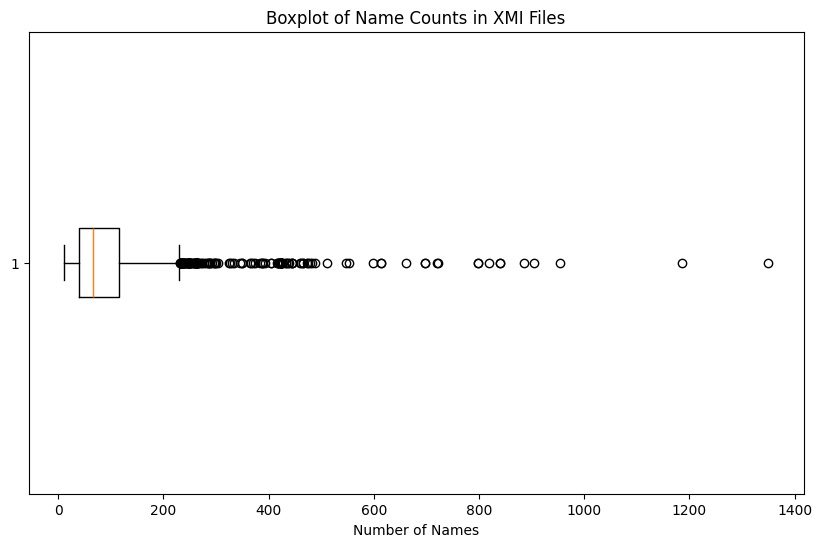

In [48]:
plt.figure(figsize=(10, 6))
plt.boxplot(df["Name Count"], vert=False)
plt.title("Boxplot of Name Counts in XMI Files")
plt.xlabel("Number of Names")
plt.show()

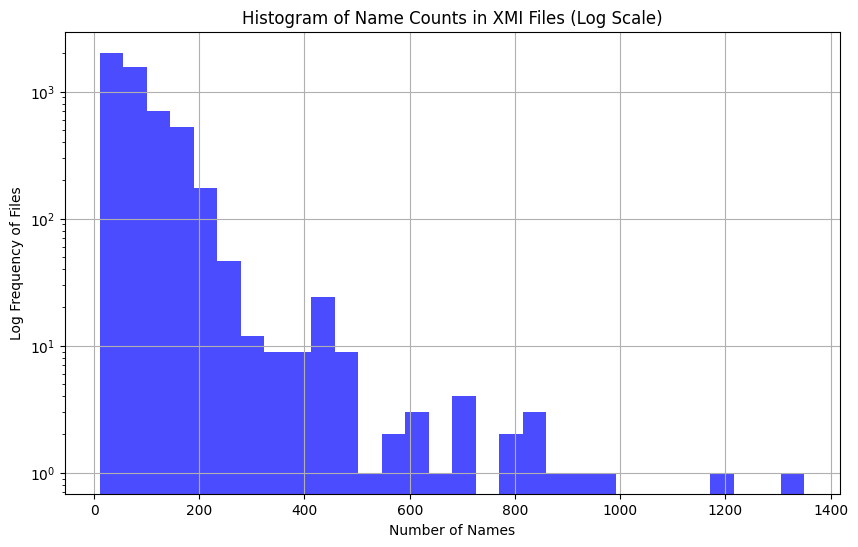

In [49]:
plt.figure(figsize=(10, 6))
plt.hist(df["Name Count"], bins=30, color="blue", alpha=0.7, log=True)
plt.title("Histogram of Name Counts in XMI Files (Log Scale)")
plt.xlabel("Number of Names")
plt.ylabel("Log Frequency of Files")
plt.grid(True)
plt.show()

Looking for models with only a few names

In [50]:
n = 5
few_names_df = df[df["Name Count"] < n]
few_names_df

,File,Name Count


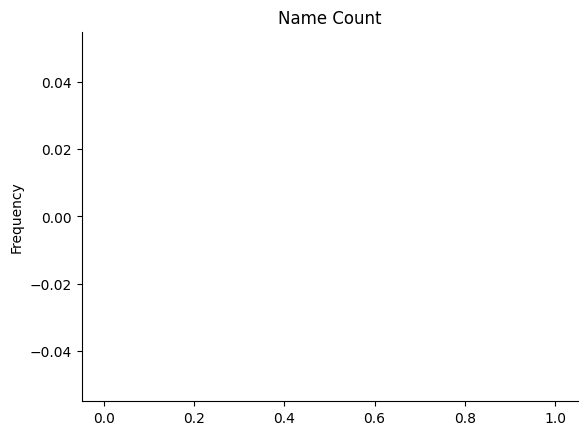

In [51]:
from matplotlib import pyplot as plt

few_names_df["Name Count"].plot(kind="hist", bins=20, title="Name Count")
plt.gca().spines[
    [
        "top",
        "right",
    ]
].set_visible(False)

Frequency of names

In [52]:
def load_names(directory):
    file_names_dict = {}
    for filename in os.listdir(directory):
        if filename.endswith(".txt"):
            file_path = os.path.join(directory, filename)
            with open(file_path, encoding="utf-8") as file:
                # Create a set of names from each file, stripping whitespace and converting to lowercase for uniformity
                names = {line.strip().lower() for line in file if line.strip()}  # Ensure non-empty lines
            file_names_dict[filename] = names
    return file_names_dict


names_dict = load_names(output_directory_without_type)

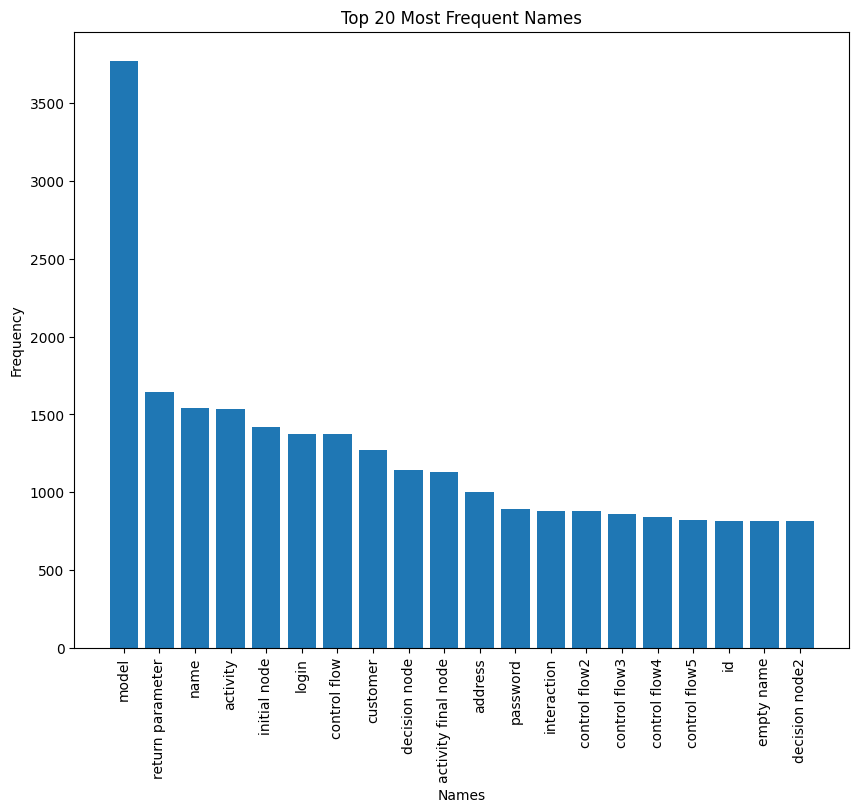

In [53]:
def plot_word_frequency(names_dict):
    all_names = [name for names in names_dict.values() for name in names]
    name_counts = Counter(all_names)
    most_common_names = name_counts.most_common(20)  # Get the top 20 most common names

    # Plotting
    plt.figure(figsize=(10, 8))
    names, counts = zip(*most_common_names)
    plt.bar(names, counts)
    plt.xlabel("Names")
    plt.ylabel("Frequency")
    plt.title("Top 20 Most Frequent Names")
    plt.xticks(rotation=90)
    plt.show()


plot_word_frequency(names_dict)

Median lenght of the names

In [54]:
def get_name_lengths(file_path):
    """Retrieve the mean and median length of names from a file."""
    with open(file_path, encoding="utf-8") as file:
        names = [line.strip() for line in file if line.strip()]
        if not names:  # Check if the list is empty
            return None, None  # Return None if no names are found

        lengths = [len(name) for name in names]  # Calculate lengths of each name
        mean_length = np.mean(lengths)
        median_length = np.median(lengths)

        return mean_length, median_length


def process_directory(directory):
    """Process all files in the specified directory and return a DataFrame with the results."""
    data = []

    # Loop over all files in the directory
    for filename in os.listdir(directory):
        if filename.endswith(".txt"):
            file_path = os.path.join(directory, filename)
            mean_length, median_length = get_name_lengths(file_path)
            if mean_length is not None and median_length is not None:  # Ensure there are names
                data.append((filename, mean_length, median_length))

    # Create DataFrame
    df = pd.DataFrame(data, columns=["File", "Mean Length", "Median Length"])
    return df

In [55]:
results_df = process_directory(output_directory_without_type)
results_df

,File,Mean Length,Median Length
0,002ca54a-bea9-469c-a218-94136d255e75.txt,9.500000,8.0
1,00319ae3-0244-4f26-bd98-982b1244fb50.txt,12.435897,13.0
2,005232b2-1223-4f5a-93a5-c32fb302a1fd.txt,13.576271,14.0
3,005741dc-cb8c-436d-bad7-4483a14bfb69.txt,9.407407,7.5
4,00804b8d-43fc-49cb-86ef-a1db731485b9.txt,12.537815,10.0
...,...,...,...
5115,__xiREBQKEeqDmNBP3mfLQg.txt,17.250000,12.0
5116,__Z-g8DNTEemjcq-iJCnVjQ.txt,11.363636,8.0
5117,___-M0L8xEeeEXb8Dudo6PQ.txt,8.119048,7.5
5118,___4B8HnhEemjiISbKferQg.txt,14.278481,13.0


In [56]:
m = 4
short_names_df = results_df[results_df["Median Length"] < m]
short_names_df

,File,Mean Length,Median Length
207,126d5419-c454-4c0f-96b0-883f521e03d0.txt,2.565217,1.0
968,57a45dc2-5f5d-4d66-9762-d53deeb86226.txt,2.565217,2.0
1363,789712f7-6a44-4e83-bb3b-6148a901014b.txt,3.255814,2.0
1965,ac195c66-7286-4ec0-9178-867f23daa855.txt,2.666667,2.0
2011,af4b2ebc-4ed5-4b7c-b82e-0d7a913781e1.txt,3.055556,2.0
...,...,...,...
5073,_zWdcgLWjEeiOktH6zvsQYA.txt,2.391304,1.0
5081,__1eBMOm0EeiV94kHgjpOMg.txt,2.844444,3.0
5099,__GYw0Om4EeiJfugOH9Y5Zg.txt,2.384615,1.0
5108,__S9WkOwQEei9dNtZPq67hQ.txt,2.315789,1.0


In [57]:
results_df[results_df["Median Length"] == m]

,File,Mean Length,Median Length
3068,_1P9sgO1hEei9dNtZPq67hQ.txt,3.882353,4.0
3232,_6LV20O1gEei9dNtZPq67hQ.txt,4.400000,4.0
3671,_EwAzIOm2EeiV94kHgjpOMg.txt,4.456522,4.0
3680,_F3qK8OmmEeiV94kHgjpOMg.txt,5.500000,4.0
3807,_GVEcwCNCEeisAYMSV00L2Q.txt,6.448980,4.0
4199,_MO_AwOmjEeiV94kHgjpOMg.txt,4.473684,4.0
4365,_p2Z6gAepEeqFfO0RhT_ZfA.txt,4.880000,4.0
4898,_xHohgOm5EeiJfugOH9Y5Zg.txt,4.736842,4.0


In [58]:
threshold_high_short_name = 0.30  # More than 30% of names must be short
threshold_low_short_name = 0.25  # At least 25% of names must be short
threshold_control_flow = 0.4  # At least 40% of names must contain "control flow"
min_name_length = 2  # Names of length 1 or 2 are considered short


def analyze_names(names):
    """Analyze the names to categorize files based on criteria"""
    short_names_count = 0
    control_flow_count = 0
    total_names = len(names)

    if total_names == 0:
        return (False, False)  # No names to analyze

    for name in names:
        if len(name.strip()) <= min_name_length:
            short_names_count += 1
        if "control flow" in name.lower():
            control_flow_count += 1

    short_name_ratio = short_names_count / total_names
    control_flow_ratio = control_flow_count / total_names

    criteria1 = short_name_ratio >= threshold_high_short_name
    criteria2 = short_name_ratio >= threshold_low_short_name and control_flow_ratio >= threshold_control_flow

    return (criteria1, criteria2)


single_char_names_criteria1 = []
single_char_names_criteria2 = []

# Iterate over files in the directory
for filename in os.listdir(output_directory_without_type):
    if filename.endswith(".txt"):
        file_path = os.path.join(output_directory_without_type, filename)
        with open(file_path, encoding="utf-8") as file:
            names = [line.strip() for line in file if line.strip()]

        criteria1, criteria2 = analyze_names(names)
        if criteria1:
            single_char_names_criteria1.append(filename)
        if criteria2:
            single_char_names_criteria2.append(filename)

# Output results
print("Flagged models with >30% short names and no 'control flow':")
for model in single_char_names_criteria1:
    print(model)

print("\nFlagged models with >=25% short names and at least 40% 'control flow':")
for model in single_char_names_criteria2:
    print(model)

Flagged models with >30% short names and no 'control flow':
126d5419-c454-4c0f-96b0-883f521e03d0.txt
57a45dc2-5f5d-4d66-9762-d53deeb86226.txt
789712f7-6a44-4e83-bb3b-6148a901014b.txt
a7ed6582-5c41-45d2-8972-ca481dde73e9.txt
ac195c66-7286-4ec0-9178-867f23daa855.txt
af4b2ebc-4ed5-4b7c-b82e-0d7a913781e1.txt
c150e670-2410-46dc-825d-67e490480bad.txt
c7693128-cf9c-4d14-b0e5-a4fa43471c22.txt
_-LbJ8OmjEeiV94kHgjpOMg.txt
_-OBQUOm2EeiV94kHgjpOMg.txt
_-oWZ4LsQEeedTfUoC-GfaA.txt
_-WDPsMUmEeeWu-SLkciAbg.txt
_00_WUOm0EeiV94kHgjpOMg.txt
_09BW0PJNEei0SKJPiR2ViA.txt
_0km_EAIUEeifsJ80ec9hDw.txt
_0kZuAPbYEeiqn80yrzdh8w.txt
_0mMLYNK1EeiczqJWtOPN4Q.txt
_1CA8QLTbEeiOktH6zvsQYA.txt
_1gaP4OdZEeiDGLvZhbPYyA.txt
_1P9sgO1hEei9dNtZPq67hQ.txt
_27wI0PJXEei0SKJPiR2ViA.txt
_2ecsAPFKEei0SKJPiR2ViA.txt
_2QmwgPJLEei0SKJPiR2ViA.txt
_4otvUOmjEeiV94kHgjpOMg.txt
_4VILsM7BEeeMV96X50GAvA.txt
_5IsCgBCfEeimSO_GhE8jew.txt
_5LYMUPFKEei0SKJPiR2ViA.txt
_6K3p0PJPEei0SKJPiR2ViA.txt
_6LV20O1gEei9dNtZPq67hQ.txt
_6uDX8MYbEeeWu-SLkciAbg.

In [59]:
len(single_char_names_criteria1)

194

In [60]:
len(single_char_names_criteria2)

10

In [61]:
two_char_pattern = re.compile(r"^[a-zA-Z]\d$", re.IGNORECASE)  # Matches "a1", "B2", etc.
letter_space_letter_pattern = re.compile(r"^[a-zA-Z]\s[a-zA-Z]$", re.IGNORECASE)  # Matches "a b", "x y", etc.

THRESHOLD = 0.3  # % of the names must be dummy to flag the model

# List to store flagged models with their dummy name percentage
matching_files = []

# Iterate through each text file in the directory
for filename in os.listdir(output_directory_without_type):
    if filename.endswith(".txt"):
        file_path = os.path.join(output_directory_without_type, filename)

        with open(file_path, encoding="utf-8") as file:
            names = [line.strip() for line in file if line.strip()]  # Remove empty lines

            if not names:
                continue  # Skip empty name lists

            # Count how many names match dummy patterns
            dummy_count = sum(
                1 for name in names if two_char_pattern.match(name) or letter_space_letter_pattern.match(name)
            )
            total_names = len(names)

            # Compute the percentage of dummy-like names
            dummy_ratio = dummy_count / total_names

            # Flag the file if the dummy ratio exceeds the threshold
            if dummy_ratio >= THRESHOLD:
                matching_files.append((filename, total_names, dummy_count, dummy_ratio))

# Sort flagged models by the highest dummy percentage
matching_files.sort(key=lambda x: x[3], reverse=True)

# Display the results
print(f"Flagged models based on dummy name percentage (Threshold: {THRESHOLD * 100}%):")
for file, total, dummy, ratio in matching_files[:25]:  # Show first 10 for preview
    print(f"{file} - {dummy}/{total} names ({ratio:.2%} dummy)")

# Save results to a file
output_file = "suspect_models_two_char_or_letter_space.txt"  # Set a path where you want the results to be saved
with open(output_file, "w", encoding="utf-8") as f:
    f.write("Files containing at least one suspicious name ('a1', 'a b', etc.):\n")
    for file in matching_files:
        f.write(f"{file}\n")

print(f"Results saved to: {output_file}")

Flagged models based on dummy name percentage (Threshold: 30.0%):
_0mMLYNK1EeiczqJWtOPN4Q.txt - 21/30 names (70.00% dummy)
_2QmwgPJLEei0SKJPiR2ViA.txt - 18/31 names (58.06% dummy)
_PUODQIBvEei-m5BAOg12zA.txt - 7/15 names (46.67% dummy)
_S6sL0PJLEei0SKJPiR2ViA.txt - 14/31 names (45.16% dummy)
_JGeN0PJNEei0SKJPiR2ViA.txt - 14/35 names (40.00% dummy)
_vVinELskEeedTfUoC-GfaA.txt - 11/28 names (39.29% dummy)
_Aa5XEPJIEei0SKJPiR2ViA.txt - 11/29 names (37.93% dummy)
__sFlwPJGEei0SKJPiR2ViA.txt - 11/29 names (37.93% dummy)
_UNGywPJHEei0SKJPiR2ViA.txt - 10/28 names (35.71% dummy)
_ViGcAMejEeiKG6QlYrIxRw.txt - 10/28 names (35.71% dummy)
_zm_csOm1EeiV94kHgjpOMg.txt - 15/42 names (35.71% dummy)
_7NOXMMUeEeeWu-SLkciAbg.txt - 16/45 names (35.56% dummy)
_LAF4MM7REeeLcIicqHdTUQ.txt - 11/31 names (35.48% dummy)
_EPZngAeqEeqFfO0RhT_ZfA.txt - 31/90 names (34.44% dummy)
_iZpTYMUfEeeWu-SLkciAbg.txt - 12/35 names (34.29% dummy)
_LwWdcO5YEeiH57IZcqf8WA.txt - 12/35 names (34.29% dummy)
_ZuZlEMUgEeeWu-SLkciAbg

In [62]:
# Extract only the filenames (first element of each tuple)
two_char_names = [entry[0] for entry in matching_files]

two_char_names

['_0mMLYNK1EeiczqJWtOPN4Q.txt',
 '_2QmwgPJLEei0SKJPiR2ViA.txt',
 '_PUODQIBvEei-m5BAOg12zA.txt',
 '_S6sL0PJLEei0SKJPiR2ViA.txt',
 '_JGeN0PJNEei0SKJPiR2ViA.txt',
 '_vVinELskEeedTfUoC-GfaA.txt',
 '_Aa5XEPJIEei0SKJPiR2ViA.txt',
 '__sFlwPJGEei0SKJPiR2ViA.txt',
 '_UNGywPJHEei0SKJPiR2ViA.txt',
 '_ViGcAMejEeiKG6QlYrIxRw.txt',
 '_zm_csOm1EeiV94kHgjpOMg.txt',
 '_7NOXMMUeEeeWu-SLkciAbg.txt',
 '_LAF4MM7REeeLcIicqHdTUQ.txt',
 '_EPZngAeqEeqFfO0RhT_ZfA.txt',
 '_iZpTYMUfEeeWu-SLkciAbg.txt',
 '_LwWdcO5YEeiH57IZcqf8WA.txt',
 '_ZuZlEMUgEeeWu-SLkciAbg.txt',
 '_6K3p0PJPEei0SKJPiR2ViA.txt',
 '_ee8GEOdeEeiDGLvZhbPYyA.txt',
 '_GhsdoAViEeqkL8atiZCKNw.txt',
 '_UB31wM9VEeeLcIicqHdTUQ.txt',
 '_HePggOmhEeiV94kHgjpOMg.txt',
 '_MEMgYLLAEee7sYPkE4-GPA.txt']

In [63]:
# Regex pattern to match names like 'att1', 'att 1', 'attA', 'att A', etc.
# dummy_name_pattern = re.compile(r'^att\s+\d+|^att\s+[A-Za-z]$', re.IGNORECASE)

# dummy_name_pattern = re.compile(r'^att[a-z0-9]$', re.IGNORECASE)


dummy_name_pattern = re.compile(r"^att(\s+[A-Za-z]|\s+\d+|[a-z0-9])?$", re.IGNORECASE)


# Function to check files for dummy names
def find_files_with_dummy_names(directory, pattern):
    dummy_files = []
    for filename in os.listdir(directory):
        if filename.endswith(".txt"):
            file_path = os.path.join(directory, filename)
            with open(file_path, encoding="utf-8") as file:
                names = file.readlines()
                # Check if any name in the file matches the dummy pattern
                if any(pattern.match(name.strip()) for name in names):
                    dummy_files.append(filename)
    return dummy_files


files_with_dummies = find_files_with_dummy_names(output_directory_without_type, dummy_name_pattern)

print("Files with dummy names:")
for file in files_with_dummies:
    print(file)

Files with dummy names:
126d5419-c454-4c0f-96b0-883f521e03d0.txt
57a45dc2-5f5d-4d66-9762-d53deeb86226.txt
789712f7-6a44-4e83-bb3b-6148a901014b.txt
ac195c66-7286-4ec0-9178-867f23daa855.txt
af4b2ebc-4ed5-4b7c-b82e-0d7a913781e1.txt
c150e670-2410-46dc-825d-67e490480bad.txt
_-LbJ8OmjEeiV94kHgjpOMg.txt
_-OBQUOm2EeiV94kHgjpOMg.txt
_-oWZ4LsQEeedTfUoC-GfaA.txt
_-WDPsMUmEeeWu-SLkciAbg.txt
_00_WUOm0EeiV94kHgjpOMg.txt
_09BW0PJNEei0SKJPiR2ViA.txt
_0km_EAIUEeifsJ80ec9hDw.txt
_0kZuAPbYEeiqn80yrzdh8w.txt
_1CA8QLTbEeiOktH6zvsQYA.txt
_1gaP4OdZEeiDGLvZhbPYyA.txt
_1P9sgO1hEei9dNtZPq67hQ.txt
_27wI0PJXEei0SKJPiR2ViA.txt
_2ecsAPFKEei0SKJPiR2ViA.txt
_2QmwgPJLEei0SKJPiR2ViA.txt
_4otvUOmjEeiV94kHgjpOMg.txt
_4VILsM7BEeeMV96X50GAvA.txt
_5IsCgBCfEeimSO_GhE8jew.txt
_5LYMUPFKEei0SKJPiR2ViA.txt
_63_60MUuEeeWu-SLkciAbg.txt
_6K3p0PJPEei0SKJPiR2ViA.txt
_6LV20O1gEei9dNtZPq67hQ.txt
_6uDX8MYbEeeWu-SLkciAbg.txt
_6Wg6QDcwEeiQp6eXyhUzBA.txt
_6zuyUM9UEeeLcIicqHdTUQ.txt
_7FnIYOdaEeiDGLvZhbPYyA.txt
_7NOXMMUeEeeWu-SLkciAbg.txt
_8

In [64]:
len(files_with_dummies)

176

In [65]:
# Regex patterns
dummy_class_pattern = re.compile(r"^class\s?[a-z0-9]$", re.IGNORECASE)  # Strictly match 'class 1', 'class a', etc.
general_class_pattern = re.compile(r"^[a-z]+", re.IGNORECASE)  # Match any class name


def classify_files(directory):
    files_fully_dummy = []
    files_mostly_valid = []
    files_mixed_classes = []

    for filename in os.listdir(directory):
        if filename.endswith(".txt"):
            file_path = os.path.join(directory, filename)
            dummy_count = 0
            valid_count = 0
            dummy_found = False  # Flag to check if any dummy name exists

            with open(file_path, encoding="utf-8") as file:
                for line in file:
                    type_name = line.strip().split(":")  # Splitting line into type and name
                    if len(type_name) < 2:  # Ensure there is a type and a name
                        continue
                    artifact_type, name = type_name[0].strip().lower(), type_name[1].strip()
                    if artifact_type == "class":  # Only process class types
                        if dummy_class_pattern.match(name):
                            dummy_count += 1
                            dummy_found = True  # Set flag on finding a dummy name
                        elif general_class_pattern.match(name):
                            valid_count += 1

            if dummy_found:  # Only process further if a dummy name was found
                # Evaluate file based on counts
                total_classes = dummy_count + valid_count
                if total_classes == 0:
                    continue  # Avoid division by zero, handle files with no class definitions

                dummy_ratio = dummy_count / total_classes
                # Define thresholds
                if dummy_ratio > 0.5:
                    files_fully_dummy.append(filename)
                elif dummy_count > 0 and dummy_ratio <= 0.13:  # Less than 13% dummy names
                    files_mixed_classes.append(filename)
                else:
                    files_mostly_valid.append(filename)

    return files_fully_dummy, files_mostly_valid, files_mixed_classes


# Classify files in the directory with type
fully_dummy, mostly_valid, mixed_classes = classify_files(output_directory_with_type)

# Display results
print("Files fully dummy:")
for file in fully_dummy:
    print(file)

print("\nFiles mostly valid (with few dummy classes):")
for file in mostly_valid:
    print(file)

print("\nFiles with a mix of dummy and non-dummy classes:")
for file in mixed_classes:
    print(file)

Files fully dummy:
023dadfd-ea30-4ea7-9de5-68ee829d327c.txt
034d066d-a498-44d9-80a3-95e1a6cf5994.txt
05464133-5a5d-4540-ab9e-41fe73631f32.txt
0627adb5-fe9d-4124-8ba2-cc78ddd9386f.txt
06d406fa-1713-49fa-a909-2c2ddfced4c2.txt
077af0cb-3d60-43e2-9863-f9a86a4b6054.txt
07b32062-8db4-400c-9714-89a871a5b952.txt
08854a3e-c154-4419-b430-773e916544f1.txt
09b6dff8-a4d9-4458-a69c-f746aef98be0.txt
0c4cfb0a-6a18-439f-b105-4cf63385a447.txt
0df155ef-8383-4fe2-9449-346ce7fa6dcf.txt
1046ef91-09c8-4b52-863b-67617432a5cf.txt
10dc9438-d1f4-4850-983f-47973fc289a9.txt
11273a2f-e0ec-4db5-90ed-21f76a88e341.txt
11fb3f20-3860-4c73-aa49-605eb820979d.txt
13fffce5-9b91-4fb6-90b4-4d2e05ce3076.txt
1721c022-76b9-4d40-a58c-076926c0e31a.txt
17489171-4771-4996-bfe8-32e5c0554572.txt
1ae96b12-231b-4739-9d54-bcfe3b1f18ed.txt
1dcfa0ab-b554-4efe-a527-f51698927cda.txt
1f2dce65-2a6d-4562-a721-8eb74e438151.txt
24c3c0b0-d931-451b-9f42-2c3ab60a3af5.txt
24fc31d2-059f-492a-88b3-a4c245b955af.txt
261c0487-6b2c-4b80-a1c6-58c2693808ba.t

In [66]:
mostly_valid

['5c7cf1d5-8cef-455c-a5bc-62cfc74d44a2.txt',
 'a2efefeb-3d2e-4e00-a927-e352fede338b.txt',
 'be4bf271-e094-43ca-b71d-2b5a7f1fe1ce.txt',
 '_3DvnUCH8EeqqcaoAsxFIeg.txt',
 '_48i_EL9vEemphpAvuifT8g.txt',
 '_8uGwcAlCEeqB3a4sRh-tuQ.txt',
 '_A7QHYOheEeiV94kHgjpOMg.txt',
 '_CPNAoEwiEeqonN_RS9oRzw.txt',
 '_ijfaIMHOEei9yqzfX9cFYA.txt',
 '_iPGWcGH0EeqK2M3E1LfZ7Q.txt',
 '_mjBXoMLHEei9yqzfX9cFYA.txt',
 '_mNc6IFrmEeiyA_1nwijzkg.txt',
 '_oE4JgIlxEeq3N_Xh6gsEIQ.txt',
 '_U_BUgOCuEee1VcqWCkiVQg.txt',
 '_V1-cwGSnEeio56zSTH7puw.txt',
 '_Z0GkwETJEeeTJ_4Vl2J2rQ.txt']

In [67]:
len(mostly_valid) + len(mixed_classes) + len(fully_dummy)

265

In [68]:
len(fully_dummy)

236

In [69]:
# Regex pattern to match entries starting with "class:" followed by "my class" optionally followed by a space and number
pattern = re.compile(r"^class:\s*my class\s?(\d+)?$", re.IGNORECASE)

l = 2

# Dictionary to hold files and counts of occurrences
files_with_my_class_counts = {}

# Iterate over all text files in the directory
for filename in os.listdir(output_directory_with_type):
    if filename.endswith(".txt"):
        file_path = os.path.join(output_directory_with_type, filename)
        count = 0
        with open(file_path, encoding="utf-8") as file:
            # Read the file line by line
            for line in file:
                line = line.strip()
                if pattern.match(line):  # Check if the line matches the pattern
                    count += 1

        if count > l:  # Check if there are more than one occurrence
            files_with_my_class_counts[filename] = count

# Output results
print("Files containing more than one 'class: my class' or 'class: my class' followed by a number:")
for file, count in files_with_my_class_counts.items():
    print(f"{file}: {count} occurrences")

Files containing more than one 'class: my class' or 'class: my class' followed by a number:
11e00c7b-8c31-49a2-9596-8200778ada27.txt: 12 occurrences
3b7929ba-5549-408c-b875-76ed5cd7e2c5.txt: 12 occurrences
894c12f0-8a66-4053-8f08-01dc0bcc8045.txt: 12 occurrences
915752ec-a8f2-4359-af10-49213a85e98d.txt: 12 occurrences
b3a60591-f65e-493e-aff3-4a33fd6717d4.txt: 12 occurrences
bbc8e86a-ee33-48a5-90ce-8bc07cded664.txt: 12 occurrences
cebfa942-8fee-496b-9dc6-ec4f50dc7443.txt: 3 occurrences
e357f27a-93f7-4f1e-8335-80c6327ecc9a.txt: 12 occurrences
e9994542-b53f-4c36-ab46-bd170204206f.txt: 12 occurrences
eff0f1ce-38f4-44e2-9ee6-d9f948ac4eb3.txt: 12 occurrences
_-kiZkK_bEee6S77dw3LIvQ.txt: 19 occurrences
_24LpMNN6EeehRMl7r1-c5g.txt: 20 occurrences
_26Xd8G7GEeeCSaocM3J-ZQ.txt: 16 occurrences
_4-G0wLyNEeedTfUoC-GfaA.txt: 3 occurrences
_5eCEkLslEeedTfUoC-GfaA.txt: 6 occurrences
_7i3gwMnkEeeM1PgT03-3Vg.txt: 20 occurrences
_9vFQwKoTEeeEQN1ZyOr-_g.txt: 9 occurrences
_bf7QYGH0EeepGY91r9Nuow.txt: 18 oc

In [70]:
# Define common dummy words (extend as needed)
dummy_keywords = {
    "my class",
    "class",
    "use case",
    "actor",
    "attribute",
    "association",
    "control flow",
    "activity",
    "decision node",
    "opaque action",
    "lifeline",
    "flow final node",
    "activity final node",
    "join node",
    "fork node",
    "initial node",
    "merge node",
    "action",
    "component",
    "ext point",
    "empty name",
    "package",
}

# Define a regex to detect numbered patterns (e.g., "my class1", "association3")
numbered_pattern = re.compile(r"(.+?)[\s_]?(\d+)$", re.IGNORECASE)

# Define thresholds for detection
SEQUENTIAL_THRESHOLD = 0.75  # % of names that follow a sequential pattern
DUMMY_WORD_THRESHOLD = 0.82  # % of names that are generic dummy words
VOCABULARY_UNIQUENESS_THRESHOLD = 3  # Minimum unique words per model

# Store flagged models
flagged_models = []

# Iterate over name files
for filename in os.listdir(output_directory_without_type):
    if filename.endswith(".txt"):
        file_path = os.path.join(output_directory_without_type, filename)
        with open(file_path, encoding="utf-8") as file:
            names = [line.strip().lower() for line in file if line.strip()]

        if not names:
            continue  # Skip empty files

        # Count occurrences of dummy words
        dummy_count = sum(1 for name in names if any(dw in name for dw in dummy_keywords))
        dummy_ratio = dummy_count / len(names)

        # Check for sequential naming patterns
        sequential_count = sum(1 for name in names if numbered_pattern.match(name))
        sequential_ratio = sequential_count / len(names)

        # Check vocabulary richness (count unique words)
        words = [word for name in names for word in name.split()]
        unique_words = set(words)

        # Flagging condition
        if (
            sequential_ratio >= SEQUENTIAL_THRESHOLD  # Too many numbered names
            or dummy_ratio >= DUMMY_WORD_THRESHOLD  # Too many generic words
            or len(unique_words) <= VOCABULARY_UNIQUENESS_THRESHOLD  # Low vocabulary richness
        ):
            flagged_models.append((filename, len(names), sequential_ratio, dummy_ratio, len(unique_words)))

# Save flagged models to a file
output_file = "flagged_dummy_models.txt"  # Set a path where you want the results to be saved
with open(output_file, "w") as f:
    f.write("File Name, Total Names, Sequential Ratio, Dummy Word Ratio, Unique Word Count\n")
    for model in flagged_models:
        f.write(f"{model[0]}, {model[1]}, {model[2]:.2f}, {model[3]:.2f}, {model[4]}\n")

print(f"Flagged dummy models saved to '{output_file}'")

Flagged dummy models saved to 'flagged_dummy_models.txt'


In [71]:
flagged_models

[('038c8775-0d9e-4bf8-b28a-29f31967db43.txt',
  45,
  0.6888888888888889,
  0.8222222222222222,
  49),
 ('0d1debf7-99b0-4e6d-8c61-6522adfa90e8.txt',
  92,
  0.967391304347826,
  0.6195652173913043,
  94),
 ('11e00c7b-8c31-49a2-9596-8200778ada27.txt',
  31,
  0.9354838709677419,
  0.6129032258064516,
  32),
 ('2c04c4c8-5dd8-4834-a6a0-5de2b53da0cb.txt',
  45,
  0.6888888888888889,
  0.8222222222222222,
  49),
 ('3b7929ba-5549-408c-b875-76ed5cd7e2c5.txt',
  31,
  0.9354838709677419,
  0.6129032258064516,
  32),
 ('44f0285e-437d-4c23-94f4-70cfe0369bca.txt',
  49,
  0.7142857142857143,
  0.8367346938775511,
  47),
 ('7181470b-67d4-4874-ab41-9aa248c3d364.txt',
  45,
  0.6888888888888889,
  0.8222222222222222,
  49),
 ('824ade0e-e227-46ff-9e6a-27c1e0de8582.txt',
  21,
  0.8095238095238095,
  0.9523809523809523,
  17),
 ('894c12f0-8a66-4053-8f08-01dc0bcc8045.txt', 32, 0.90625, 0.625, 33),
 ('915752ec-a8f2-4359-af10-49213a85e98d.txt',
  31,
  0.9354838709677419,
  0.6129032258064516,
  32),
 ('

In [72]:
flagged_dummy_models = []

with open("flagged_dummy_models.txt", encoding="utf-8") as f:
    next(f)  # Skip the header line
    for line in f:
        filename = line.split(",")[0].strip()  # Extract filename from CSV
        flagged_dummy_models.append(filename)  # Append to list

In [73]:
len(flagged_dummy_models)

111

In [74]:
# Function to process files, excluding the identified files
def process_files(directory, exclude_files):
    processed_files = []
    for filename in os.listdir(directory):
        if filename not in exclude_files:
            file_path = os.path.join(directory, filename)
            processed_files.append(file_path)
    return processed_files

In [75]:
files_with_few_names = few_names_df["File"].tolist()
files_with_short_names = short_names_df["File"].tolist()
files_with_my_class_names = list(files_with_my_class_counts.keys())


# Combine all files to exclude into a set to ensure uniqueness
# files_to_exclude = set(files_with_dummies + mostly_valid + fully_dummy + files_with_few_names + files_with_short_names + flagged_dummy_models + two_char_names + files_with_my_class_names + single_char_names_criteria1 + single_char_names_criteria2)
files_to_exclude = set(
    files_with_dummies
    + mostly_valid
    + fully_dummy
    + files_with_few_names
    + files_with_short_names
    + flagged_dummy_models
    + files_with_my_class_names
    + single_char_names_criteria1
    + single_char_names_criteria2
)

# Process the dataset, excluding the files with dummy, specific class names, and few or too short names
remaining_files = process_files(output_directory_without_type, files_to_exclude)
len(remaining_files)

4546

In [76]:
len(files_to_exclude)

574

In [77]:
files_to_exclude

{'023dadfd-ea30-4ea7-9de5-68ee829d327c.txt',
 '034d066d-a498-44d9-80a3-95e1a6cf5994.txt',
 '038c8775-0d9e-4bf8-b28a-29f31967db43.txt',
 '05464133-5a5d-4540-ab9e-41fe73631f32.txt',
 '0627adb5-fe9d-4124-8ba2-cc78ddd9386f.txt',
 '06d406fa-1713-49fa-a909-2c2ddfced4c2.txt',
 '077af0cb-3d60-43e2-9863-f9a86a4b6054.txt',
 '07b32062-8db4-400c-9714-89a871a5b952.txt',
 '08854a3e-c154-4419-b430-773e916544f1.txt',
 '09b6dff8-a4d9-4458-a69c-f746aef98be0.txt',
 '0c4cfb0a-6a18-439f-b105-4cf63385a447.txt',
 '0d1debf7-99b0-4e6d-8c61-6522adfa90e8.txt',
 '0df155ef-8383-4fe2-9449-346ce7fa6dcf.txt',
 '1046ef91-09c8-4b52-863b-67617432a5cf.txt',
 '10dc9438-d1f4-4850-983f-47973fc289a9.txt',
 '11273a2f-e0ec-4db5-90ed-21f76a88e341.txt',
 '11e00c7b-8c31-49a2-9596-8200778ada27.txt',
 '11fb3f20-3860-4c73-aa49-605eb820979d.txt',
 '126d5419-c454-4c0f-96b0-883f521e03d0.txt',
 '13fffce5-9b91-4fb6-90b4-4d2e05ce3076.txt',
 '1721c022-76b9-4d40-a58c-076926c0e31a.txt',
 '17489171-4771-4996-bfe8-32e5c0554572.txt',
 '1ae96b12

In [78]:
with open("dummy_files_to_exclude.txt", "w") as file:
    # Write each ID without the .txt extension
    for filename in files_to_exclude:
        id_without_txt = filename.replace(".txt", "")
        file.write(id_without_txt + "\n")

Checking how many unique dummy models we found that aren't labeled as such in the dataset, and also how many we missed

In [79]:
# Extract just the file names (UUIDs) from dummy_models["id"]
dummy_model_ids = set(dummy_models["id"].str.extract(r"([^/]+)\.xmi$")[0].dropna())
unknown_model_ids = set(unknown_models["id"].str.extract(r"([^/]+)\.xmi$")[0].dropna())

# Extract just the file names (UUIDs) from files_to_exclude (remove .txt extension)
excluded_files = set(file.replace(".txt", "") for file in files_to_exclude)

# Find unique models in each list
unique_dummy_models = dummy_model_ids - excluded_files  # In dummy_models but NOT in files_to_exclude
unique_excluded_models = excluded_files - dummy_model_ids  # In files_to_exclude but NOT in dummy_models

# Print summary
print(f"Total dummy models: {len(dummy_model_ids)}")
print(f"Total excluded files: {len(excluded_files)}")
print(f"Unique dummy models (not in excluded): {len(unique_dummy_models)}")
print(f"Unique excluded models (not in dummy): {len(unique_excluded_models)}")

# Save results to files
with open("unique_dummy_models.txt", "w") as f:
    for model in unique_dummy_models:
        f.write(model + "\n")

with open("unique_excluded_models.txt", "w") as f:
    for model in unique_excluded_models:
        f.write(model + "\n")

print("Unique dummy models saved to 'unique_dummy_models.txt'")
print("Unique excluded models saved to 'unique_excluded_models.txt'")

Total dummy models: 606
Total excluded files: 574
Unique dummy models (not in excluded): 60
Unique excluded models (not in dummy): 28
Unique dummy models saved to 'unique_dummy_models.txt'
Unique excluded models saved to 'unique_excluded_models.txt'


In [80]:
# Find unique models in each list
unique_unknown_models = unknown_model_ids - excluded_files  # In unknown_models but NOT in files_to_exclude
unique_excluded_models_unknown = excluded_files - unknown_model_ids  # In files_to_exclude but NOT in unknown_models

13 models we found as dummy are tagged as unknown

In [81]:
len(unique_excluded_models_unknown)

561

Some cases for manual inspection

In [82]:
# Path to the file that contains the filenames
excluded_models_file = "unique_excluded_models.txt"

# Load filenames from the excluded models file
with open(excluded_models_file, encoding="utf-8") as f:
    filenames = [line.strip() + ".txt" for line in f if line.strip()]  # Append .txt

# Regex pattern to match "control flow" and variations (e.g., "controlflow1", "control flow 1")
control_flow_pattern = re.compile(r"\bcontrol\s?flow\s?\d*\b", re.IGNORECASE)

# List to store filenames where "control flow" is NOT found in the content
files_without_control_flow = []

# Iterate over each file in the output directory
for filename in filenames:
    file_path = os.path.join(output_directory_without_type, filename)

    # Check if the file exists in the directory before reading
    if os.path.exists(file_path):
        with open(file_path, encoding="utf-8") as file:
            content = file.read()
            # If "control flow" is NOT found in the content, add to the list
            if not control_flow_pattern.search(content):
                files_without_control_flow.append(filename)

# Print results
print(f"Total files checked: {len(filenames)}")
print(f"Files without 'control flow': {len(files_without_control_flow)}")

Total files checked: 28
Files without 'control flow': 11


In [83]:
files_without_control_flow

['_X1iQ4MUeEeeWu-SLkciAbg.txt',
 '_CPNAoEwiEeqonN_RS9oRzw.txt',
 '_V1-cwGSnEeio56zSTH7puw.txt',
 '_oE4JgIlxEeq3N_Xh6gsEIQ.txt',
 '_iPGWcGH0EeqK2M3E1LfZ7Q.txt',
 '_YtZi0NjvEeeQi8PFukjNiw.txt',
 '_XhxOMPJXEei0SKJPiR2ViA.txt',
 'be4bf271-e094-43ca-b71d-2b5a7f1fe1ce.txt',
 '_MBZ9oPbFEeeL5uCiN2F57w.txt',
 'a2efefeb-3d2e-4e00-a927-e352fede338b.txt',
 '_8uGwcAlCEeqB3a4sRh-tuQ.txt']

# Duplicate detection

### Hashing for exact duplicates

In [84]:
def get_file_hash(file_path):
    """Compute a SHA-256 hash for the extracted UML names stored in a text file."""
    try:
        with open(file_path, encoding="utf-8") as file:
            content = file.read().strip().lower()  # Read and normalize text content
            return hashlib.sha256(content.encode()).hexdigest()  # Hash the content
    except Exception as e:
        print(f"Error reading file {file_path}: {e}")
        return None

In [85]:
hash_to_files = defaultdict(list)
output_txt_file = "hashing_results.txt"

start_time = time.time()

for file_name in os.listdir(output_directory_with_type):
    # if file_name.endswith(".txt") and file_name not in files_to_exclude:
    if file_name.endswith(".txt"):
        file_path = os.path.join(output_directory_with_type, file_name)
        file_hash = get_file_hash(file_path)

        if file_hash:
            hash_to_files[file_hash].append(file_path)

end_time = time.time()
execution_time = end_time - start_time

duplicate_files = {h: files for h, files in hash_to_files.items() if len(files) > 1}
unique_files = {h: files[0] for h, files in hash_to_files.items() if len(files) == 1}

# Save results to a text file
with open(output_txt_file, "w", encoding="utf-8") as txt_file:
    txt_file.write(f"Execution time: {execution_time:.2f} seconds\n\n")
    txt_file.write("=== Duplicate UML Name Files Detected ===\n")
    if duplicate_files:
        for file_hash, files in duplicate_files.items():
            txt_file.write(f"\nDuplicate Group (Hash: {file_hash}):\n")
            for file in files:
                txt_file.write(f"  - {os.path.basename(file)}\n")
    else:
        txt_file.write("No duplicate name files found.\n")

    txt_file.write("\n=== Unique UML Name Files (No Duplicates) ===\n")
    if unique_files:
        for file_hash, file in unique_files.items():
            txt_file.write(f"\nUnique File (Hash: {file_hash}):\n  - {os.path.basename(file)}\n")
    else:
        txt_file.write("No unique files found.\n")

# Print execution time
print(f"\nExecution time: {execution_time:.2f} seconds")
print(f"Results saved to: {output_txt_file}")


Execution time: 0.70 seconds
Results saved to: hashing_results.txt


In [86]:
len(unique_files)

2701

Pie chart shows 'unique files' vs the 'number of files found in the duplicate groups'. There's 376 distinct groups into which the duplicates are categorized, so technicaly a total amount of unique files would be 'unique files' + one representative of each duplicate group.


=== Dataset Statistics ===
Total files processed: 5120
Total unique files: 2701
Total duplicate files: 2419
Number of duplicate groups: 376


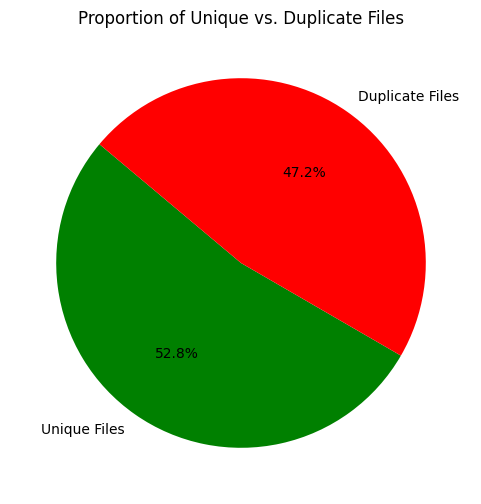

In [87]:
# Path to the output file
output_txt_file = "hashing_results.txt"

# Data structures to store parsed results
duplicate_counts = []
unique_list = []
total_files = 0
total_duplicates = 0
total_unique = 0

# Read the results from the text file
with open(output_txt_file, encoding="utf-8") as file:
    lines = file.readlines()

# Parse the file contents
current_duplicate_group_size = 0
parsing_duplicates = False
parsing_uniques = False

for line in lines:
    line = line.strip()

    # Detect the start of duplicate groups
    if "=== Duplicate UML Name Files Detected ===" in line:
        parsing_duplicates = True
        continue

    # Detect the start of unique files
    if "=== Unique UML Name Files" in line:
        parsing_duplicates = False
        parsing_uniques = True
        continue

    # Process duplicate groups
    if parsing_duplicates:
        if line.startswith("Duplicate Group (Hash:"):
            # Store the previous group size
            if current_duplicate_group_size > 0:
                duplicate_counts.append(current_duplicate_group_size)
            current_duplicate_group_size = 0  # Reset for next group
        elif line.startswith("-"):
            current_duplicate_group_size += 1  # Count files in group

    # Process unique files
    if parsing_uniques and line.startswith("-"):
        unique_list.append(line.split("-")[-1].strip())

# Store the last duplicate group size
if current_duplicate_group_size > 0:
    duplicate_counts.append(current_duplicate_group_size)

# Compute total counts
total_duplicates = sum(duplicate_counts)
total_unique = len(unique_list)
total_files = total_duplicates + total_unique

# Print statistics
print("\n=== Dataset Statistics ===")
print(f"Total files processed: {total_files}")
print(f"Total unique files: {total_unique}")
print(f"Total duplicate files: {total_duplicates}")
print(f"Number of duplicate groups: {len(duplicate_counts)}")


labels = ["Unique Files", "Duplicate Files"]
sizes = [total_unique, total_duplicates]
colors = ["green", "red"]

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct="%1.1f%%", colors=colors, startangle=140)
plt.title("Proportion of Unique vs. Duplicate Files")
plt.show()

In [88]:
def read_file(file_path):
    try:
        with open(file_path, encoding="utf-8") as file:
            return file.read().strip()
    except Exception as e:
        print(f"Error reading file {file_path}: {e}")
        return None


files_content = []
filenames = []

# Add one representative from each duplicate group
for file_paths in duplicate_files.values():
    representative_file = file_paths[0]  # Just take the first file as the representative
    content = read_file(representative_file)
    if content:
        files_content.append(content)
        filenames.append(representative_file)

# Add all unique files
for file_path in unique_files.values():
    content = read_file(file_path)
    if content:
        files_content.append(content)
        filenames.append(file_path)

After finding the exact duplicates, we take the 'unique files' + one representative of each duplicate group, and do near-duplicate detection to also remove items that are not exactly identical but share substantial similarities, such as a base model with minor modifications (like an additional class for example). This is done with tf-idf representation + cosine similarity.
The txt file that stores the results this time under the  "=== Unique Files ===" tag stores truly uniqe files, as well as one representative fo each duplicate group!

In [89]:
start_time = time.time()

# Compute TF-IDF vectors
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(files_content)

# Compute cosine similarity matrix
similarity_matrix = cosine_similarity(tfidf_matrix)

# Set a similarity threshold
similarity_threshold = 0.8

# Initialize groups of duplicates
duplicate_groups = defaultdict(list)
unique_files_indices = set(range(len(filenames)))  # Track indices of potentially unique files

# Efficient file comparison
for i in range(len(filenames)):
    found_group = False
    file1 = os.path.basename(filenames[i])

    for group_id, members in list(duplicate_groups.items()):
        for member_index in members:
            if member_index != i and similarity_matrix[i][member_index] > similarity_threshold:
                duplicate_groups[group_id].append(i)
                found_group = True
                unique_files_indices.discard(i)  # Remove from unique files if found duplicate
                break
        if found_group:
            break

    # If no existing group is similar, start a new group
    if not found_group and i in unique_files_indices:
        duplicate_groups[file1].append(i)

# Write results
near_duplicate_file = "near_duplicate_results.txt"
with open(near_duplicate_file, "w", encoding="utf-8") as file:
    file.write("=== Near Duplicate Files Detected ===\n")
    for group_id, indices in duplicate_groups.items():
        if len(indices) > 1:
            file.write(f"\n{group_id} has the following near duplicates:\n")
            for index in indices:
                file_name = os.path.basename(filenames[index])
                if file_name != group_id:
                    file.write(f"  - {file_name}\n")

    file.write("\n=== Unique Files ===\n")
    for index in unique_files_indices:
        file.write(f"  - {os.path.basename(filenames[index])}\n")

execution_time = time.time() - start_time
print(f"\nExecution time for near duplicate search: {execution_time:.2f} seconds")
print(f"Results saved to: {near_duplicate_file}")


Execution time for near duplicate search: 3.28 seconds
Results saved to: near_duplicate_results.txt



=== Dataset Statistics ===
Total files processed: 3077
Total unique files: 1107
Total duplicate files: 1970
Number of duplicate groups: 248


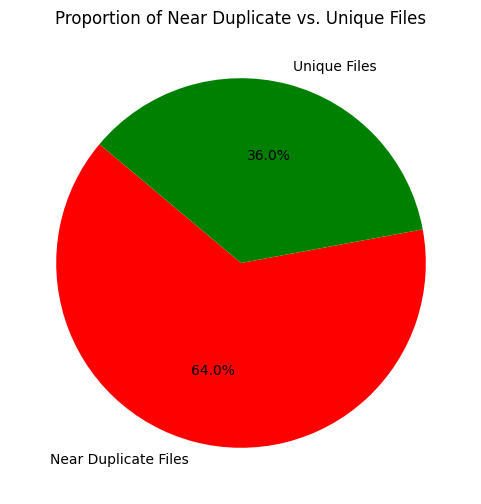

In [90]:
# Count the number of near duplicates and unique files
near_duplicate_count = sum(len(indices) for indices in duplicate_groups.values() if len(indices) > 1)
number_of_duplicate_groups = sum(1 for indices in duplicate_groups.values() if len(indices) > 1)
unique_file_count = len(unique_files_indices) - number_of_duplicate_groups
total_files_processed = near_duplicate_count + unique_file_count

# Print dataset statistics
print("\n=== Dataset Statistics ===")
print(f"Total files processed: {total_files_processed}")
print(f"Total unique files: {unique_file_count}")
print(f"Total duplicate files: {near_duplicate_count}")
print(f"Number of duplicate groups: {number_of_duplicate_groups}")

# Labels and sizes for the pie chart
labels = ["Near Duplicate Files", "Unique Files"]
sizes = [near_duplicate_count, unique_file_count]
colors = ["red", "green"]

# Create the pie chart
plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct="%1.1f%%", colors=colors, startangle=140)
plt.title("Proportion of Near Duplicate vs. Unique Files")
plt.show()

# Language detection

In [167]:
def process_file(file_path):
    """Process a single txt file to detect language."""
    language_counts = defaultdict(int)
    file_languages = set()

    try:
        with open(file_path, encoding="utf-8") as file:
            text = file.read()

        if text.strip():  # Ensure it's not empty or whitespace
            detected_language = detect(text)
            language_counts[detected_language] += 1
            file_languages.add(detected_language)
    except Exception as e:
        print(f"Error processing file {file_path}: {e}")

    return file_path, language_counts, file_languages

In [168]:
# Ensure consistent results from langdetect
DetectorFactory.seed = 42

# Directory containing the text files
directory = "modelset_uml_names"
# File to save results
result_file_path = "language_detection_results_modelset.txt"  # Define your path where you want your results

# List all text files in the directory
file_paths = [os.path.join(directory, file) for file in os.listdir(directory) if file.endswith(".txt")]

# Process files sequentially
all_language_counts = defaultdict(int)
files_with_languages = defaultdict(set)

for file_path in file_paths:
    _, language_counts, file_languages = process_file(file_path)
    for lang, count in language_counts.items():
        all_language_counts[lang] += count
    files_with_languages[file_path].update(file_languages)

# Write results to a text file
with open(result_file_path, "w", encoding="utf-8") as result_file:
    result_file.write("=== Language Distribution Across Dataset ===\n")
    for language, count in all_language_counts.items():
        result_file.write(f"{language}: {count}\n")

    result_file.write("\n=== Files with Detected Languages ===\n")
    for file, languages in files_with_languages.items():
        result_file.write(f"{file}: {', '.join(languages) if languages else 'No language detected'}\n")

print(f"\nLanguage detection completed. Results saved to '{result_file_path}'.")


Language detection completed. Results saved to 'language_detection_results_modelset.txt'.


In [169]:
summary_file = "language_detection_results_modelset.txt"

In [170]:
def extract_non_english_files(summary_file):
    non_english_files = []
    parsing_languages = False

    with open(summary_file, encoding="utf-8") as file:
        for line in file:
            if line.strip() == "=== Files with Detected Languages ===":
                parsing_languages = True
            elif parsing_languages and line.strip():
                parts = line.split(":")
                file_path = parts[0].strip()
                language = parts[1].strip()
                # Extract only the filename from the path
                filename = file_path.split("/")[-1]
                # Check if English is not the detected language
                if language != "en":
                    non_english_files.append(filename)

    return non_english_files

Checking the difference in numbers of the detected English models and the ones thatw ere labeled as such

In [171]:
english_models_df

,id,domain,tags,language,purpose,simplified_id
0,repo-genmymodel-uml/data/64d73a9a-d42d-4090-b6...,travel,NaN,english,unknown,64d73a9a-d42d-4090-b6ce-9496e444dcf0
1,repo-genmymodel-uml/data/eb2e3754-86b5-4347-84...,store,NaN,english,unknown,eb2e3754-86b5-4347-8434-71e3135183f5
2,repo-genmymodel-uml/data/484652f6-e5a4-46ab-be...,computer,api|api,english,unknown,484652f6-e5a4-46ab-befb-dfb8f7641371
3,repo-genmymodel-uml/data/437ab337-a90b-4f71-b6...,computer,api|api,english,unknown,437ab337-a90b-4f71-b624-4453324e5fa9
4,repo-genmymodel-uml/data/be831d41-e22f-4096-86...,shopping,NaN,english,comercial,be831d41-e22f-4096-86a1-336770a46d93
...,...,...,...,...,...,...
5115,repo-genmymodel-uml/data/15eeaaf5-edea-4355-a5...,booking,NaN,english,unknown,15eeaaf5-edea-4355-a546-cb6748d9f563
5116,repo-genmymodel-uml/data/e7a6aab2-9695-4ab2-97...,restaurant,hierarchy,english,unknown,e7a6aab2-9695-4ab2-97c3-9ae2cbeccf8b
5117,repo-genmymodel-uml/data/2dd271e1-4923-4a0b-b7...,booking,restaurant,english,unknown,2dd271e1-4923-4a0b-b70c-2d3523493a84
5118,repo-genmymodel-uml/data/b202a006-e9dc-4cd5-af...,health,hospital,english,unknown,b202a006-e9dc-4cd5-af2c-ea250c57c63e


In [172]:
english_files_labeled = english_models_df["simplified_id"].tolist()

In [173]:
len(english_files_labeled)

4497

In [174]:
def extract_english_files(summary_file):
    english_files = []
    parsing_languages = False

    with open(summary_file, encoding="utf-8") as file:
        for line in file:
            if line.strip() == "=== Files with Detected Languages ===":
                parsing_languages = True
            elif parsing_languages and line.strip():
                parts = line.split(":")
                file_path = parts[0].strip()
                language = parts[1].strip()
                # Extract only the filename from the path
                filename = file_path.split("/")[-1]
                # Check if English is not the detected language

                if language == "en":
                    english_files.append(filename)

    return english_files

In [175]:
english_files = extract_english_files(summary_file)
english_files = [os.path.basename(file) for file in english_files]

In [176]:
english_files

['002ca54a-bea9-469c-a218-94136d255e75.txt',
 '00319ae3-0244-4f26-bd98-982b1244fb50.txt',
 '005232b2-1223-4f5a-93a5-c32fb302a1fd.txt',
 '005741dc-cb8c-436d-bad7-4483a14bfb69.txt',
 '00804b8d-43fc-49cb-86ef-a1db731485b9.txt',
 '009c586e-c334-44e9-bc54-cda8cd222031.txt',
 '0135a497-5a9f-4032-b123-eaca643929e9.txt',
 '0147ca54-a618-4801-848d-d1eb35c894e1.txt',
 '0168e18b-5474-44f5-b26c-eeb8e190f382.txt',
 '017c44d4-8411-4119-9034-276940fd859b.txt',
 '01933ada-508b-4ae6-9d66-36352594013b.txt',
 '01a633d1-e68f-42c5-9bfe-20c3f305238c.txt',
 '01d8334c-c7f6-48e4-b3e7-4f72224ddbfd.txt',
 '01f98f2d-03a9-4998-90de-88d830d460e6.txt',
 '02210c0f-1b01-4f84-b5ce-ac64d4295ba9.txt',
 '02215e76-e093-4888-8efc-dad5d6ea5c1b.txt',
 '023dadfd-ea30-4ea7-9de5-68ee829d327c.txt',
 '026af861-f4c0-431c-9e00-c28743088ee4.txt',
 '028d758f-d6e9-4580-b0c5-83f928ac0a53.txt',
 '02c46879-5dcd-484e-a106-bb6ddf616d17.txt',
 '02c4d4d4-a521-4df9-a341-451518e9dc6a.txt',
 '032c334d-a24a-4757-835f-2b15911226fb.txt',
 '034d066d

In [177]:
english_files = [
    re.search(r"([\w-]+)\.txt", filename).group(1)
    for filename in english_files
    if re.search(r"([\w-]+)\.txt", filename)
]

In [178]:
english_files

['002ca54a-bea9-469c-a218-94136d255e75',
 '00319ae3-0244-4f26-bd98-982b1244fb50',
 '005232b2-1223-4f5a-93a5-c32fb302a1fd',
 '005741dc-cb8c-436d-bad7-4483a14bfb69',
 '00804b8d-43fc-49cb-86ef-a1db731485b9',
 '009c586e-c334-44e9-bc54-cda8cd222031',
 '0135a497-5a9f-4032-b123-eaca643929e9',
 '0147ca54-a618-4801-848d-d1eb35c894e1',
 '0168e18b-5474-44f5-b26c-eeb8e190f382',
 '017c44d4-8411-4119-9034-276940fd859b',
 '01933ada-508b-4ae6-9d66-36352594013b',
 '01a633d1-e68f-42c5-9bfe-20c3f305238c',
 '01d8334c-c7f6-48e4-b3e7-4f72224ddbfd',
 '01f98f2d-03a9-4998-90de-88d830d460e6',
 '02210c0f-1b01-4f84-b5ce-ac64d4295ba9',
 '02215e76-e093-4888-8efc-dad5d6ea5c1b',
 '023dadfd-ea30-4ea7-9de5-68ee829d327c',
 '026af861-f4c0-431c-9e00-c28743088ee4',
 '028d758f-d6e9-4580-b0c5-83f928ac0a53',
 '02c46879-5dcd-484e-a106-bb6ddf616d17',
 '02c4d4d4-a521-4df9-a341-451518e9dc6a',
 '032c334d-a24a-4757-835f-2b15911226fb',
 '034d066d-a498-44d9-80a3-95e1a6cf5994',
 '03736215-ef06-40b0-99bc-dfa8bdb4d35b',
 '038a6b1d-f9aa-

In [179]:
len(english_files)

4443

In [180]:
unique_labeled = set(english_files_labeled) - set(english_files)

In [181]:
len(unique_labeled)

273

In [182]:
unique_ours = set(english_files) - set(english_files_labeled)

In [183]:
len(unique_ours)

219

Extarcting non-English files to add to the exclusion list

In [184]:
# Extract non-English files from the summary and update the exclusion list
non_english_files = extract_non_english_files(summary_file)
non_english_files = [os.path.basename(file) for file in non_english_files]

In [185]:
len(non_english_files)

677

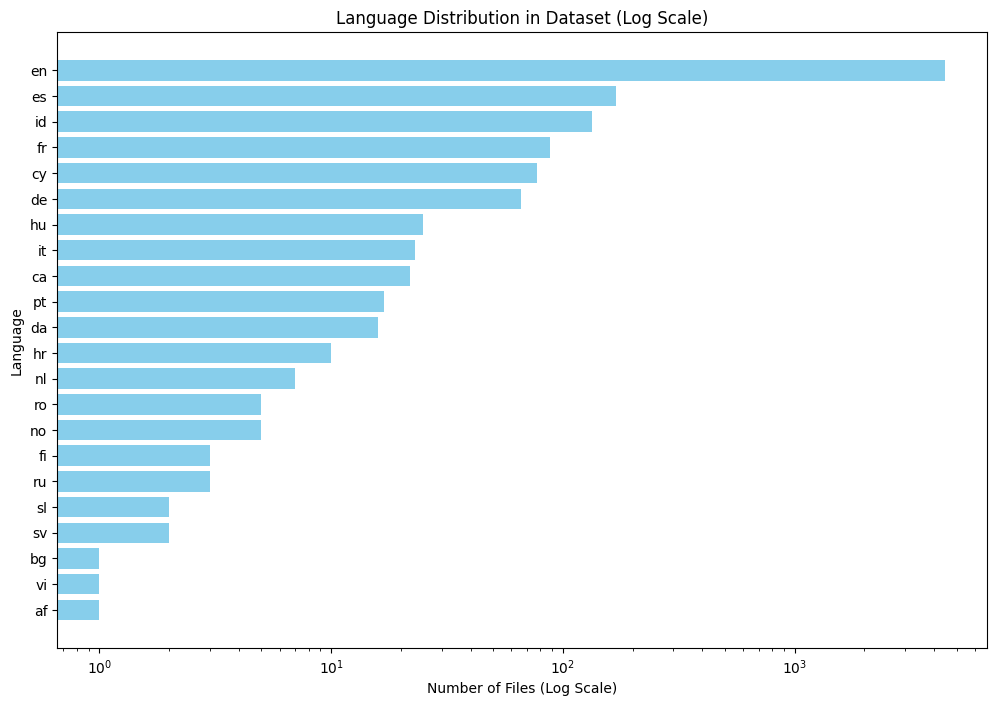

In [186]:
def extract_language_counts(file_path):
    with open(file_path, encoding="utf-8") as file:
        lines = file.readlines()

    # Start reading the file after this line
    start_index = lines.index("=== Language Distribution Across Dataset ===\n") + 1
    end_index = lines.index("=== Files with Detected Languages ===\n")

    language_counts = {}
    for line in lines[start_index:end_index]:
        if ":" in line:
            language, count = line.strip().split(":")
            language_counts[language.strip()] = int(count.strip())

    return language_counts


# Extract language counts from file
language_counts = extract_language_counts(summary_file)

# Convert to DataFrame for easier plotting
df_languages = pd.DataFrame(list(language_counts.items()), columns=["Language", "Count"])

# Sort the DataFrame by count for better visualization
df_languages.sort_values("Count", ascending=False, inplace=True)

# Plotting
plt.figure(figsize=(12, 8))
plt.barh(df_languages["Language"], df_languages["Count"], color="skyblue")
plt.xlabel("Number of Files (Log Scale)")
plt.ylabel("Language")
plt.title("Language Distribution in Dataset (Log Scale)")
plt.xscale("log")  # Set the x-axis to a log scale
plt.gca().invert_yaxis()  # Invert y axis to have the highest count at the top
plt.show()

In [187]:
# Remove '.txt' extension and convert to a set
non_english_files_set = {file[:-4] for file in non_english_files}

# Compute the difference
remaining_ids = unique_unknown_models.difference(non_english_files_set)

# Output the remaining unique unknown model IDs
remaining_ids

{'0dfed87f-aee3-4b53-b0eb-516c93a001d7',
 '144782cb-cfe0-4cb3-b542-23e465f8dc71',
 '2fac5aeb-4470-4506-b247-c791421c8b6e',
 '31751b83-b990-492f-a5f1-a5285dce0d13',
 '3a1fe8fa-916f-4c40-90f5-219b75c98232',
 '3ad16260-3ca7-439e-ace4-e204fa0c7bd9',
 '59037aa5-bf07-4b06-a042-41f763e276f7',
 '59fb5ee2-0bb9-4e13-a66e-46c82355ca9d',
 '69133377-e295-4e99-ad2a-371a8bfa0f77',
 '774a0070-f9b6-415c-b852-cda24c6ddc81',
 '78f3cf14-b6de-4daf-8397-c27fd2c24e1f',
 '7fcb8a92-8971-48b4-b800-f3f958fc4338',
 '8a2420c6-8bef-4d19-8b4e-6665feb0f5bb',
 '907bf4df-5757-4245-b266-9d37aa6d82a3',
 '90a3e48a-a0b1-44fb-a9f9-cfb8bfa05b57',
 '987a342a-495b-41eb-ae6b-01ddf64a7c51',
 '98cc9d19-6b56-4692-bc8a-62d47b6c4aa6',
 '_-4cScMoFEeeM1PgT03-3Vg',
 '_-RgCUDpsEemHAp3Hj3YZWw',
 '_0Gtw8BpmEeqPCsas7676rw',
 '_0pvHsD1REei384rcaJKdxw',
 '_0r5yAN9oEemZHaiox11UDg',
 '_1I-m4OKYEee1VcqWCkiVQg',
 '_20oEcMfWEeiZ3fREAmKE6g',
 '_26n44MPGEeeWu-SLkciAbg',
 '_28W4UD1WEei-35aR1OYsWA',
 '_2D8DMN3KEeeAyLDAJ12_fg',
 '_2g8ZcNXhEeehRMl7r1-c

In [188]:
len(remaining_ids)

199

# Extracting datasets for the reproducibility study 

As needed for the paper "Can explainable artificial intelligence support software modelers in model comprehension?": just removing duplicates

In [189]:
# Path to the text file containing the near duplicate results
results_file_path = "near_duplicate_results.txt"

# List to hold the unique file names
unique_file_names = []

# Flag to determine if we are in the section containing unique file names
parsing_uniques = False

# Open the file and read line by line
with open(results_file_path, encoding="utf-8") as file:
    for line in file:
        # Check if we've reached the section with unique file names
        if "=== Unique Files ===" in line:
            parsing_uniques = True
            continue
        elif parsing_uniques:
            if line.startswith("  - "):  # Unique file names are prefixed with "  - "
                # Extract the file name and add to the list

                file_name = line.strip()[2:-4]
                unique_file_names.append(file_name)

In [190]:
len(unique_file_names)

1355

In [191]:
# Add a new column that simplifies the 'id' for matching
merged_df["simplified_id"] = merged_df["id"].str.extract(r"data/([^.]+)")

# Filter the DataFrame to only include rows where the simplified ID is in the filtered_unique_files list
filtered_df = merged_df[merged_df["simplified_id"].isin(unique_file_names)]

filtered_df

,id,diagram_ad,diagram_cd,diagram_comp,diagram_interaction,diagram_sm,diagram_usecase,elements,type_Activity,type_Actor,...,type_Package,type_Property,type_Relationship,type_State,type_Transition,type_UseCase,category,tags,language,simplified_id
0,repo-genmymodel-uml/data/_WJKFoOBcEeeAyLDAJ12_...,1.0,5.0,NaN,NaN,NaN,1.0,123.0,1.0,1.0,...,1.0,22.0,6.0,0.0,0.0,0.0,computer-ui,NaN,english,_WJKFoOBcEeeAyLDAJ12_fg
1,repo-genmymodel-uml/data/_grOBAOs7EeiJfugOH9Y5...,NaN,8.0,NaN,NaN,NaN,NaN,56.0,0.0,0.0,...,1.0,20.0,3.0,0.0,0.0,0.0,computer-videogames,videgame,english,_grOBAOs7EeiJfugOH9Y5Zg
2,repo-genmymodel-uml/data/_3e5Z4BBDEeqa8dopbpYH...,NaN,33.0,NaN,NaN,NaN,17.0,726.0,0.0,17.0,...,1.0,203.0,106.0,0.0,0.0,47.0,unknown,NaN,rusian,_3e5Z4BBDEeqa8dopbpYHJg
3,repo-genmymodel-uml/data/_zRSRMDEsEemjcq-iJCnV...,NaN,3.0,NaN,NaN,NaN,NaN,32.0,0.0,0.0,...,1.0,15.0,3.0,0.0,0.0,0.0,unknown,NaN,unknown,_zRSRMDEsEemjcq-iJCnVjQ
4,repo-genmymodel-uml/data/_1vnlQNqPEeiJYbNjsZ3w...,1.0,NaN,1.0,NaN,NaN,2.0,53.0,1.0,2.0,...,1.0,4.0,5.0,0.0,0.0,3.0,dummy,NaN,english,_1vnlQNqPEeiJYbNjsZ3wUw
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5070,repo-genmymodel-uml/data/6508e918-17c5-426f-a0...,NaN,12.0,NaN,NaN,NaN,2.0,171.0,0.0,2.0,...,2.0,58.0,25.0,0.0,0.0,12.0,booking-flight,NaN,english,6508e918-17c5-426f-a0aa-46c227f024c0
5072,repo-genmymodel-uml/data/_73KhUNGGEeib2vfQ4l86...,NaN,NaN,NaN,NaN,NaN,3.0,112.0,0.0,3.0,...,1.0,28.0,15.0,0.0,0.0,9.0,bank,NaN,spanish,_73KhUNGGEeib2vfQ4l86Yg
5075,repo-genmymodel-uml/data/_09BW0PJNEei0SKJPiR2V...,NaN,8.0,NaN,NaN,NaN,NaN,91.0,0.0,0.0,...,1.0,11.0,8.0,0.0,0.0,0.0,dummy,NaN,english,_09BW0PJNEei0SKJPiR2ViA
5091,repo-genmymodel-uml/data/_UBxr4HGQEemkSo3PkdMx...,NaN,NaN,NaN,1.0,NaN,1.0,213.0,0.0,1.0,...,1.0,1.0,1.0,0.0,0.0,0.0,computing,api|api,english,_UBxr4HGQEemkSo3PkdMxbg


In [192]:
filtered_df.to_csv("modelset_dataframe_deduplicated.csv", index=False)  # Set your path

As needed for the paper "Machine Learning Methods for Model Classification: A Comparative Study": on top of removing duplicates, we need to remove dummy models and non-English models, and then on top of that also drop any leftover models that the authors of the original dataset tagged as 'dummy' and 'unknown'. 

Excluding those files that are dummy and are non-English 

In [193]:
# Remove the '.txt' extension from each filename in files_to_exclude
files_to_exclude_stripped = {filename[:-4] for filename in files_to_exclude}

# Convert the list to a set
unique_file_names_set = set(unique_file_names)

# Exclude the unwanted files
cleaned_file_names = unique_file_names_set - files_to_exclude_stripped

# Convert the set back to a list if needed
cleaned_file_names = list(cleaned_file_names)
len(cleaned_file_names)

1293

In [194]:
# Strip the .txt extension from non_english_files
non_english_files_cleaned = [file[:-4] for file in non_english_files]

# Filter out non-English files from the unique file names list
filtered_unique_files = [file for file in cleaned_file_names if file not in non_english_files_cleaned]

len(filtered_unique_files)

971

Filtering out the models with tags dummy and unknown

In [195]:
# Convert Series to sets
dummy_models_set = set(dummy_models["id"].apply(lambda x: x.split("/")[-1].split(".")[0]))
unknown_models_set = set(unknown_models["id"].apply(lambda x: x.split("/")[-1].split(".")[0]))

# Convert list to set and remove the common elements
filtered_unique_files_set = set(filtered_unique_files)
cleaned_unique_files = filtered_unique_files_set - dummy_models_set - unknown_models_set

# Convert set back to list if necessary
final_files = list(cleaned_unique_files)

In [196]:
len(final_files)

868

Filtering out those categories that have less than 10 models

In [197]:
further_filtered_df = merged_df[merged_df["simplified_id"].isin(final_files)]

further_filtered_df

,id,diagram_ad,diagram_cd,diagram_comp,diagram_interaction,diagram_sm,diagram_usecase,elements,type_Activity,type_Actor,...,type_Package,type_Property,type_Relationship,type_State,type_Transition,type_UseCase,category,tags,language,simplified_id
0,repo-genmymodel-uml/data/_WJKFoOBcEeeAyLDAJ12_...,1.0,5.0,NaN,NaN,NaN,1.0,123.0,1.0,1.0,...,1.0,22.0,6.0,0.0,0.0,0.0,computer-ui,NaN,english,_WJKFoOBcEeeAyLDAJ12_fg
1,repo-genmymodel-uml/data/_grOBAOs7EeiJfugOH9Y5...,NaN,8.0,NaN,NaN,NaN,NaN,56.0,0.0,0.0,...,1.0,20.0,3.0,0.0,0.0,0.0,computer-videogames,videgame,english,_grOBAOs7EeiJfugOH9Y5Zg
7,repo-genmymodel-uml/data/_1oIk0CMrEemOV5tdt4HL...,NaN,8.0,NaN,NaN,NaN,NaN,52.0,0.0,0.0,...,1.0,12.0,7.0,0.0,0.0,0.0,computer-videogames,NaN,english,_1oIk0CMrEemOV5tdt4HL0w
8,repo-genmymodel-uml/data/567e86da-32a1-4732-b1...,NaN,NaN,NaN,NaN,NaN,3.0,59.0,0.0,3.0,...,1.0,14.0,8.0,0.0,0.0,5.0,inventory,NaN,english,567e86da-32a1-4732-b1fa-c861037be2b4
9,repo-genmymodel-uml/data/_fHYv0MjvEemburp-dOaT...,NaN,2.0,NaN,NaN,NaN,NaN,63.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,computing,api|api,english,_fHYv0MjvEemburp-dOaTWg
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5052,repo-genmymodel-uml/data/4bafa4ec-40ad-4dc6-83...,NaN,NaN,1.0,NaN,NaN,4.0,142.0,0.0,4.0,...,1.0,32.0,21.0,0.0,0.0,16.0,restaurant-pizza,NaN,english,4bafa4ec-40ad-4dc6-83c3-b610c4304607
5063,repo-genmymodel-uml/data/_9dBG8OWIEeekKLRLyKXO...,NaN,NaN,1.0,NaN,NaN,2.0,56.0,0.0,2.0,...,1.0,12.0,9.0,0.0,0.0,7.0,elevator,NaN,english,_9dBG8OWIEeekKLRLyKXO4Q
5064,repo-genmymodel-uml/data/_Bc9JsMXuEem1OJTSTdVZ...,NaN,NaN,NaN,NaN,NaN,9.0,135.0,0.0,9.0,...,1.0,32.0,17.0,0.0,0.0,12.0,rental-car,NaN,english,_Bc9JsMXuEem1OJTSTdVZsw
5070,repo-genmymodel-uml/data/6508e918-17c5-426f-a0...,NaN,12.0,NaN,NaN,NaN,2.0,171.0,0.0,2.0,...,2.0,58.0,25.0,0.0,0.0,12.0,booking-flight,NaN,english,6508e918-17c5-426f-a0aa-46c227f024c0


In [198]:
# Count the number of models in each category
category_counts = further_filtered_df["category"].value_counts()

# Filter categories with fewer than 10 models
small_categories = category_counts[category_counts < 10].index

# Filter DataFrame to only those rows where the category is in small_categories
small_category_models = further_filtered_df[further_filtered_df["category"].isin(small_categories)].copy()

small_category_models.loc[:, "base_id"] = small_category_models["id"].apply(
    lambda x: os.path.splitext(os.path.basename(x))[0]
)

# Show models in categories with fewer than 10 instances
print(small_category_models[["base_id", "category"]])

                                   base_id              category
0                  _WJKFoOBcEeeAyLDAJ12_fg           computer-ui
8     567e86da-32a1-4732-b1fa-c861037be2b4             inventory
17    c4e873fa-475e-45b5-bb9a-5df4c1c60578                 store
23                 _podzQJTgEeiilJ4tAEXZQQ             inventory
28                 _XmDa4GYdEeepGY91r9Nuow         clientsupport
...                                    ...                   ...
4947               _EP4VMMqMEemfA78eeeotcQ           recruitment
4971               _Pd3bQAVcEeipbtix-oa2Dg       store-marketing
4987               _8xxzAOfNEeiDGLvZhbPYyA           car-parking
5025  140c8d89-5dad-4e09-a4b0-6ff6c0b4dd28  employee-recruitment
5052  4bafa4ec-40ad-4dc6-83c3-b610c4304607      restaurant-pizza

[135 rows x 2 columns]


In [199]:
exclude_ids_set = set(small_category_models["base_id"])

# Filter the list to exclude any IDs present in the 'small_category_models'
further_filtered_files = [file_id for file_id in final_files if file_id not in exclude_ids_set]

# Display the filtered list
len(further_filtered_files)

733

In [200]:
further_filtered_files

['_lL9bAIPZEeeveJPbhFhy-g',
 '_DcnrgK5rEee6S77dw3LIvQ',
 '1f0b1bd2-fd4f-41c4-86b1-11c366bd93dd',
 'ed579ed2-3855-4d27-bb14-5387d9ca589e',
 '_DcfikLfVEee7sYPkE4-GPA',
 '6a08a8f0-b912-4989-9183-e22aa2ad28c8',
 '_3UpZwFMqEemuQ-TjUfVNTA',
 '_vVelsHWtEeiFX4HwoivBqg',
 'e4819d62-167e-42ec-b717-e07695b85ed6',
 '_CC450CluEeqqcaoAsxFIeg',
 '_grOBAOs7EeiJfugOH9Y5Zg',
 '112b87bf-98fd-434b-aab5-3be6bdba09e2',
 '_aYApMJ2tEeiGsdp6eB6oaw',
 '720d7c7c-a669-4d07-b251-cdc4cb049048',
 '_1hi7cI4lEemvGpFNVkS7NQ',
 '_hg8r0PQSEeiy0d_yUThzLQ',
 '_uAm74B7PEemK4rmwmdOnYw',
 '_qH-PEKL1EemlGeJsLESUmg',
 '6b55c892-8808-4d11-ac33-f72bf318d92f',
 '0c84f7f7-87ec-4d13-adb5-b892d53cee71',
 '78dcb9ae-10fd-4b3b-b288-5fc729a69a34',
 '_mP7fkHXaEeeZ3IbHHpTTiA',
 '0f655284-443a-464f-91f2-aa6c28ff831a',
 '3eefbfd8-17c8-4279-960f-412c397848a1',
 '_LTqG4NFiEeeLcIicqHdTUQ',
 'c199679e-b557-48d6-b84e-61d6beeba809',
 '_9TBCsHGUEemkSo3PkdMxbg',
 '8f65f707-dbf0-4c0a-9c21-d4c61e0227d1',
 '_fYTTwLejEem8I_zdXKdSGw',
 '2022e893-a0e0-47f

Finally we need to transform our filtered dataset into the json format the authors use with their ml models.

In [202]:
base_directory = "repo-genmymodel-uml/data/"
extension = ".xmi"

# Adjust the IDs to form the full path names and create a DataFrame for merging
finalGoodIds_df = pd.DataFrame({"id": [f"{base_directory}{id}{extension}" for id in further_filtered_files]})

# Merging to align and order the categories with the IDs in finalGoodIds_df
merged = pd.merge(finalGoodIds_df, uml_df_metadata[["id", "category"]], on="id", how="left")

# Extract the labels in the correct order
final_labels = merged["category"].tolist()

finalGoodIds = merged["id"].tolist()

print(final_labels)

['shopping', 'smarthouse', 'socialnetwork', 'bank', 'smarthouse', 'health', 'course', 'bank-atm', 'booking-flight', 'restaurant', 'computer-videogames', 'shopping', 'elevator', 'library', 'shopping', 'health', 'booking-room', 'smarthouse', 'bank-transactions', 'booking-room', 'library', 'library', 'booking-room', 'computer-videogames', 'shopping', 'booking-room', 'shopping', 'health', 'socialnetwork', 'restaurant', 'library', 'booking-room', 'booking-room', 'shopping', 'health', 'smarthouse', 'booking-room', 'shopping', 'bank-atm', 'course', 'smarthouse', 'bank', 'health', 'shopping-cart', 'bank-atm', 'smarthouse', 'employee', 'shopping-cart', 'booking-room', 'bank-atm', 'smarthouse', 'computer-videogames', 'library', 'booking-flight', 'shopping', 'library', 'library', 'smarthouse', 'booking-room', 'library', 'smarthouse', 'bank-atm', 'course', 'computing', 'restaurant', 'smarthouse', 'health', 'computer-library', 'smarthouse', 'bank', 'library', 'smarthouse', 'restaurant', 'shopping',

In [203]:
finalGoodIds

['repo-genmymodel-uml/data/_lL9bAIPZEeeveJPbhFhy-g.xmi',
 'repo-genmymodel-uml/data/_DcnrgK5rEee6S77dw3LIvQ.xmi',
 'repo-genmymodel-uml/data/1f0b1bd2-fd4f-41c4-86b1-11c366bd93dd.xmi',
 'repo-genmymodel-uml/data/ed579ed2-3855-4d27-bb14-5387d9ca589e.xmi',
 'repo-genmymodel-uml/data/_DcfikLfVEee7sYPkE4-GPA.xmi',
 'repo-genmymodel-uml/data/6a08a8f0-b912-4989-9183-e22aa2ad28c8.xmi',
 'repo-genmymodel-uml/data/_3UpZwFMqEemuQ-TjUfVNTA.xmi',
 'repo-genmymodel-uml/data/_vVelsHWtEeiFX4HwoivBqg.xmi',
 'repo-genmymodel-uml/data/e4819d62-167e-42ec-b717-e07695b85ed6.xmi',
 'repo-genmymodel-uml/data/_CC450CluEeqqcaoAsxFIeg.xmi',
 'repo-genmymodel-uml/data/_grOBAOs7EeiJfugOH9Y5Zg.xmi',
 'repo-genmymodel-uml/data/112b87bf-98fd-434b-aab5-3be6bdba09e2.xmi',
 'repo-genmymodel-uml/data/_aYApMJ2tEeiGsdp6eB6oaw.xmi',
 'repo-genmymodel-uml/data/720d7c7c-a669-4d07-b251-cdc4cb049048.xmi',
 'repo-genmymodel-uml/data/_1hi7cI4lEemvGpFNVkS7NQ.xmi',
 'repo-genmymodel-uml/data/_hg8r0PQSEeiy0d_yUThzLQ.xmi',
 'repo-gen

In [204]:
def read_model_text(id):
    file_path = os.path.join("modelset_uml_names", f"{id}.txt")
    try:
        with open(file_path, encoding="utf-8") as file:
            content = " ".join([line.strip() for line in file if line.strip()])
        return content
    except FileNotFoundError:
        print(f"File not found: {file_path}")
        return None


final_docs = [read_model_text(id) for id in further_filtered_files if read_model_text(id) is not None]

In [205]:
random.seed(123)

# Prepare the final dataset for saving
data_entries = [
    {"names": doc, "label": label, "id": id_}
    for doc, label, id_ in zip(final_docs, final_labels, finalGoodIds)
    if doc is not None
]

# Shuffle the data entries randomly
random.shuffle(data_entries)

# Saving to JSON with precise formatting
output_path = "./replication_package_MM_Classification/package/data/modelset-uml-our.json"

output_dir = os.path.dirname(output_path)

# Ensure the directory exists
if output_dir:
    os.makedirs(output_dir, exist_ok=True)

with open(output_path, "w", encoding="utf-8") as f:
    f.write('{"data":[')  # Start the JSON array
    first = True
    for entry in data_entries:
        if not first:
            f.write(", ")
        else:
            first = False
        # Convert each entry to JSON string
        json_entry = json.dumps(entry, ensure_ascii=False)
        # Replace comma followed by no space with comma followed by one space
        json_entry = json_entry.replace(',"', ', "')
        f.write(json_entry)
    f.write("]}")  # Close the JSON array and object

print(f"Data shuffled and saved to {output_path}")

Data shuffled and saved to ./replication_package_MM_Classification/package/data/modelset-uml-our.json


In [206]:
# Count the frequency of each label
label_counts = Counter(final_labels)

# Print the counts
for label, count in label_counts.items():
    print(f"{label}: {count}")

shopping: 86
smarthouse: 83
socialnetwork: 21
bank: 20
health: 64
course: 42
bank-atm: 37
booking-flight: 18
restaurant: 27
computer-videogames: 103
elevator: 12
library: 65
booking-room: 45
bank-transactions: 11
shopping-cart: 17
employee: 28
computing: 23
computer-library: 10
travel: 10
rental-car: 11
